In [105]:
#EJ1
#importo las librerias necesarias 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [106]:
#EJ1
#importo las librerias necesarias 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [107]:
#subo los dos data frames
df_2005 = pd.read_stata("C:/Users/morad/OneDrive/Desktop/CIENCIA DE DATOS/GitHub/ciencia_de_datos_G16/ciencia_de_datos_G16_TP1/ciencia_de_datos_G16/TP1/datos/Individual_t105.dta")
df_2025 = pd.read_excel("C:/Users/morad/OneDrive/Desktop/CIENCIA DE DATOS/GitHub/ciencia_de_datos_G16/ciencia_de_datos_G16_TP1/ciencia_de_datos_G16/TP1/datos/usu_individual_T125.xls.xlsx")

In [108]:
df_2005.sample(5)

,CODUSU,nro_hogar,componente,h15,ano4,trimestre,region,mas_500,aglomerado,pondera,...,deccfr,ideccfr,rdeccfr,gdeccfr,pdeccfr,adeccfr,pj1_1,pj2_1,pj3_1,idimpp
16488,136495,1.0,4.0,Sí,2005.0,1er. Trimestre,NOA,S,Gran Tucumán - Tafí Viejo,414.0,...,01,01,01,01,,01,0.0,0.0,0.0,00000
6872,228349,1.0,1.0,Sí,2005.0,1er. Trimestre,Gran Buenos Aires,S,Partidos del GBA,1239.0,...,06,,06,06,,07,0.0,0.0,0.0,00000
42717,262043,1.0,4.0,Sí,2005.0,1er. Trimestre,Pampeana,S,Mar del Plata - Batán,170.0,...,07,07,07,06,,06,0.0,0.0,0.0,00000
24900,172916,1.0,5.0,0.0,2005.0,1er. Trimestre,Cuyo,S,Gran Mendoza,353.0,...,01,01,01,01,,01,0.0,0.0,0.0,00000
12135,251741,1.0,6.0,0.0,2005.0,1er. Trimestre,NOA,N,Jujuy - Palpalá,156.0,...,03,04,05,,04,05,0.0,0.0,0.0,00000


In [109]:
df_2025.sample(5)

,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,...,V21_03_M,V22_01_M,V22_02_M,V22_03_M,P_DECCF,P_RDECCF,P_GDECCF,P_PDECCF,P_IDECCF,P_ADECCF
2356,TQSMNOPRXHLMTMCDEIJAH00875827,2025,1,1,6,1,1,S,33,2898,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
22737,TQRMNORQVHKNOOCDEIIAD00859186,2025,1,1,2,1,1,S,32,3346,...,0,0,0,0,8.0,7.0,7.0,NaN,NaN,5.0
42976,TQRMNOQYXHLOLRCDEHJGH00853911,2025,1,1,3,1,40,S,23,614,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
18441,TQRMNORPTHMNLLCDEFJAH00879485,2025,1,1,1,1,43,N,3,232,...,0,0,70000,0,7.0,7.0,NaN,7.0,7.0,6.0
12765,TQRMNOPUUHJMKQCDEIOAH00875292,2025,1,1,3,1,43,N,38,93,...,0,0,0,0,5.0,5.0,NaN,5.0,5.0,5.0


In [110]:
#Los nombres de las variables en df_2005 estan en minuscula y en df_2025 estan en mayuscula. 
#Estandarizo poniendo todo en mayuscula
df_2005.columns = df_2005.columns.str.upper()

In [111]:
#ESATNDARIZO Y UNIFICO REGION
#Primero pongo todo en un mismo formato en 2005 asi queda todo en mauscula y sin espacios demas para que sea mas facil armar el diccionario
df_2005["REGION"] = df_2005["REGION"].str.strip().str.upper()


In [112]:
df_2005.sample(3)

,CODUSU,NRO_HOGAR,COMPONENTE,H15,ANO4,TRIMESTRE,REGION,MAS_500,AGLOMERADO,PONDERA,...,DECCFR,IDECCFR,RDECCFR,GDECCFR,PDECCFR,ADECCFR,PJ1_1,PJ2_1,PJ3_1,IDIMPP
25244,198739,1.0,2.0,Sí,2005.0,1er. Trimestre,CUYO,S,Gran Mendoza,327.0,...,02,02,02,02,,02,0.0,0.0,0.0,00000
7323,238502,1.0,5.0,0.0,2005.0,1er. Trimestre,GRAN BUENOS AIRES,S,Partidos del GBA,661.0,...,02,,02,02,,02,0.0,0.0,0.0,00000
45922,221960,1.0,3.0,Sí,2005.0,1er. Trimestre,PATAGÓNICA,N,Río Gallegos,116.0,...,04,05,03,,05,02,0.0,0.0,0.0,00000


In [113]:
# Hago un diccionario de las etiquetas  de la variable REGION y el numero que quiero que aparezca en cada etiqueta para que quede igual en las dos bases de datos
region_map = {
    "GRAN BUENOS AIRES": 1,
    "NOA": 40,
    "NEA": 41,
    "CUYO": 42,
    "PAMPEANA": 43,
    "PATAGÓNICA": 44  
}

# Mapear
df_2005["REGION"] = df_2005["REGION"].map(region_map)

In [114]:
#Elijo una region, 44 (patagonica)
# Filtrar solamente la región 44 en ambos dataframes
df_2005 = df_2005[df_2005["REGION"] == 44]
df_2025 = df_2025[df_2025["REGION"] == 44]

# Veo cuántas filas quedaron en cada base
print("Filas en df_2005 (Región 44):", len(df_2005))
print("Filas en df_2025 (Región 44):", len(df_2025))

Filas en df_2005 (Región 44): 3229
Filas en df_2025 (Región 44): 5359


In [115]:
# PH Patagonia (2005 + 2025) → Esquema 2025 ===
# df_2005 y df_2025 ya cargados, columnas en MAYÚSCULAS y REGION==44.

import pandas as pd
import numpy as np
import re, unicodedata

# ---------- Helpers ----------
def _norm_txt(x: object) -> str:
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')  # quita tildes
    s = re.sub(r'[–—]', '-', s)  # normaliza guiones
    s = re.sub(r'\s+', ' ', s)   # colapsa espacios
    return s.upper()

def _to_int(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce").astype("Int64")

def _map_exact_or_contains(series: pd.Series, mapping: dict) -> pd.Series:
    """Mapea texto → código. Si no matchea exacto, prueba 'contains' con la clave más larga."""
    if series.dtype.kind in "iu":  # int
        return series.astype("Int64")
    if series.dtype.kind == "f":  # float
        return _to_int(series)
    s = series.astype(str).map(_norm_txt)

    # normalizamos claves del mapping
    map_norm = { _norm_txt(k): v for k, v in mapping.items() }
    keys_sorted = sorted(map_norm.keys(), key=len, reverse=True)

    out = s.map(map_norm)  # exact
    # fallback contains
    mask = out.isna() & s.notna()
    if mask.any():
        vals = s[mask]
        res = []
        for val in vals:
            hit = None
            for k in keys_sorted:
                if k and isinstance(val, str) and k in val:
                    hit = map_norm[k]
                    break
            res.append(hit)
        out.loc[mask] = pd.Series(res, index=vals.index).astype('float')
    return _to_int(out)

def _map_binary_si_no(series: pd.Series, yes=("SI","SÍ"), no=("NO",)) -> pd.Series:
    if series.dtype.kind in "iu":
        return _to_int(series).replace({2:0, 9:pd.NA})
    s = series.astype(str).map(_norm_txt)
    out = s.map(lambda v: 1 if v in set(map(_norm_txt, yes)) else (0 if v in set(map(_norm_txt, no)) else pd.NA))
    return out.astype("Int64")

# ---------- Diccionarios de mapeo (referencia 2025) ----------
# AGLOMERADO (incluye Patagonia + varios del ejemplo)
AGLO_MAP = {
    "GRAN LA PLATA": 2,
    "BAHIA BLANCA - CERRI": 3,
    "GRAN ROSARIO": 4,
    "GRAN SANTA FE": 5,
    "GRAN PARANA": 6,
    "POSADAS": 7,
    "GRAN RESISTENCIA": 8,
    "CDRO. RIVADAVIA - RADA TILLY": 9,
    "COMODORO RIVADAVIA - RADA TILLY": 9,
    "GRAN MENDOZA": 10,
    "CORRIENTES": 12,
    "GRAN CORDOBA": 13,
    "CONCORDIA": 14,
    "FORMOSA": 15,
    "NEUQUEN - PLOTTIER": 17,
    "SANTIAGO DEL ESTERO - LA BANDA": 18,
    "JUJUY - PALPALA": 19,
    "RIO GALLEGOS": 20,
    "GRAN CATAMARCA": 22,
    "SALTA": 23,
    "LA RIOJA": 25,
    "SAN LUIS - EL CHORRILLO": 26,
    "GRAN SAN JUAN": 27,
    "GRAN TUCUMAN - TAFI VIEJO": 29,
    "SANTA ROSA - TOAY": 30,
    "USHUAIA - RIO GRANDE": 31,
    "CIUDAD DE BUENOS AIRES": 32,
    "PARTIDOS DEL GBA": 33,
    "MAR DEL PLATA - BATAN": 34,
    "RIO CUARTO": 36,
    # nuevos patagonia 2025
    "RAWSON - TRELEW": 91,
    "VIEDMA - CARMEN DE PATAGONES": 93,
}

CH04_MAP = {'VARON':1,'HOMBRE':1,'MASCULINO':1,'MUJER':2,'FEMENINO':2}

CH07_MAP = {
    'UNIDO':1,'CONVIVIENTE':1,'VIVE EN PAREJA':1,
    'CASADO':2,'CASADA':2,
    'SEPARADO O DIVORCIADO':3,'SEPARADO':3,'DIVORCIADO':3,
    'VIUDO':4,'VIUDA':4,
    'SOLTERO':5,'SOLTERA':5
}

# CH08 (cobertura de salud) – exactos + combinaciones
CH08_EXACT = {
    'OBRA SOCIAL (INCLUYE PAMI)':1,
    'MUTUAL/PREPAGA/SERVICIO DE EMERGENCIA':2,
    'PLANES Y SEGUROS PUBLICOS':3,
    'NO PAGA NI LE DESCUENTAN':4,
    'NS./NR.':9
}
CH08_COMBOS = {
    'OBRA SOCIAL Y MUTUAL/PREPAGA/SERVICIO DE EMERGENCIA':12,
    'OBRA SOCIAL Y PLANES Y SEGUROS PUBLICOS':13,
    'MUTUAL/PREPAGA/SERVICIO DE EMERGENCIA/PLANES Y SEGUROS PUBLI':23,
    'MUTUAL/PREPAGA/SERVICIO DE EMERGENCIA/PLANES Y SEGUROS PUBLICOS':23,
    'OBRA SOCIAL, MUTUAL/PREPAGA/SERVICIO DE EMERGENCIA Y PLANES':123,
}
def _map_ch08(series: pd.Series) -> pd.Series:
    if series.dtype.kind in "iu":
        return series.astype("Int64")
    if series.dtype.kind == "f":
        return _to_int(series)
    s = series.astype(str).map(_norm_txt)
    out = s.map(CH08_EXACT)
    # combos (exact/contains)
    mask = out.isna() & s.notna()
    if mask.any():
        out.loc[mask] = s.loc[mask].map(lambda v: next((code for k,code in CH08_COMBOS.items() if _norm_txt(k) in v), pd.NA))
    # patrones
    def detect(v):
        if pd.isna(v): return pd.NA
        vv = str(v)
        if "OBRA SOCIAL" in vv and "MUTUAL" in vv and "PLANES" in vv: return 123
        if "OBRA SOCIAL" in vv and "MUTUAL" in vv: return 12
        if "OBRA SOCIAL" in vv and "PLANES" in vv: return 13
        if "MUTUAL" in vv and "PLANES" in vv: return 23
        if "OBRA SOCIAL" in vv or "PAMI" in vv: return 1
        if "MUTUAL" in vv or "PREPAGA" in vv or "SERVICIO DE EMERGENCIA" in vv: return 2
        if "PLANES" in vv or "SEGUROS PUBLICOS" in vv: return 3
        if "NO PAGA" in vv: return 4
        if "NS" in vv and "NR" in vv: return 9
        return pd.NA
    mask2 = out.isna() & s.notna()
    if mask2.any():
        out.loc[mask2] = s.loc[mask2].map(detect)
    return _to_int(out)

# NIVEL_ED (dos versiones en tu ejemplo; tomamos la de abajo)
NIVEL_ED_MAP = {
    'PRIMARIO INCOMPLETO (INCLUYE EDUCACION ESPECIAL)': 1,
    'PRIMARIO COMPLETO': 2,
    'SECUNDARIO INCOMPLETO': 3,
    'SECUNDARIO COMPLETO': 4,
    'SUPERIOR Y UNIVERSITARIO INCOMPLETO': 5,
    'SUPERIOR Y UNIVERSITARIO COMPLETO': 6,
    'SIN INSTRUCCION': 7,
    'NS/NR': 9
}

ESTADO_MAP = {
    'OCUPADO': 1,
    'DESOCUPADO': 2,
    'INACTIVO': 3,
    'MENOR DE 10 ANOS': 4, 'MENOR DE 10 AÑOS': 4
}
def _map_estado(series: pd.Series) -> pd.Series:
    if series.dtype.kind in "iu":
        return _to_int(series)
    if series.dtype.kind == "f":
        return _to_int(series)
    s = series.astype(str).map(_norm_txt)
    out = s.map(ESTADO_MAP)
    # entrevistas no realizadas → 0
    out = out.where(~s.str.contains("ENTREVISTA INDIVIDUAL NO REALIZADA", na=False), 0)
    return _to_int(out)

CAT_INAC_MAP = {
    'JUBILADO/PENSIONADO': 1, 'JUBILADO':1, 'JUBILADA':1, 'PENSIONADO':1, 'PENSIONADA':1,
    'RENTISTA': 2,
    'ESTUDIANTE': 3,
    'AMA DE CASA': 4, 'QUEHACERES DEL HOGAR':4,
    'MENOR DE 6 ANOS': 5, 'MENOR DE 6 AÑOS': 5,
    'DISCAPACITADO': 6, 'DISCAPACITADA': 6,
    'OTROS': 7, 'OTRO':7
}

CAT_OCUP_MAP = {
    'PATRON': 1, 'PATRON O EMPLEADOR':1, 'EMPLEADOR':1,
    'CUENTA PROPIA': 2, 'TRABAJADOR POR CUENTA PROPIA':2,
    'OBRERO O EMPLEADO': 3, 'EMPLEADO':3, 'OBRERO':3,
    'TRABAJADOR FAMILIAR SIN REMUNERACION': 4, 'FAMILIAR SIN REMUNERACION':4,
    'NS/NR': 9
}

CH03_MAP = {
    "JEFE": 1,
    "CONYUGE/PAREJA": 2, "CONYUGE / PAREJA": 2, "CÓNYUGE/PAREJA": 2,
    "HIJO/HIJASTRO": 3,
    "YERNO/NUERA": 4,
    "NIETO": 5,
    "MADRE/PADRE": 6,
    "SUEGRO": 7,
    "HERMANO": 8,
    "OTROS FAMILIARES": 9,
    "NO FAMILIARES": 10
}

# CH09 (vive con ambos padres / etc.)
CH09_MAP = {'SI':1,'NO':2,'MENOR DE 2 ANOS':3,'MENOR DE 2 AÑOS':3}

# CH10 (asistencia histórica, según tu amiga)
CH10_MAP = {
    'SI, ASISTE': 1,
    'NO ASISTE, PERO ASISTIO': 2,
    'NO ASISTE, PERO ASISTIÓ': 2,
    'NUNCA ASISTIO': 3, 'NUNCA ASISTIÓ': 3
}

CH11_MAP = {'PUBLICO':1,'PRIVADO':2,'NS/NR':9}

CH12_MAP = {
    'JARDIN/PREESCOLAR': 1, 'JARDIN - PREESCOLAR':1,
    'PRIMARIO': 2,
    'EGB': 3,
    'SECUNDARIO': 4,
    'POLIMODAL': 5,
    'TERCIARIO': 6,
    'UNIVERSITARIO': 7,
    'POSGRADO UNIVERSITARIO': 8,
    'EDUCACION ESPECIAL (DISCAPACITADO)': 9
}

CH14_MAP = {
    'NINGUNO':0,'PRIMERO':1,'SEGUNDO':2,'TERCERO':3,'CUARTO':4,'QUINTO':5,
    'SEXTO':6,'SEPTIMO':7,'OCTAVO':8,'NOVENO':9,
    'EDUCACION ESPECIAL':98,'NS/NR':99
}

CH15_MAP = {
    'EN ESTA LOCALIDAD':1,
    'EN OTRA LOCALIDAD':2,
    'EN OTRA PROVINCIA (ESPECIFICAR)':3,
    'EN UN PAIS LIMITROFE':4, 'EN UN PAIS LIMÍTROFE':4,
    'EN OTRO PAIS':5, 'EN OTRO PAÍS':5,
    'NS/NR':9
}

CH16_MAP = {
    'EN ESTA LOCALIDAD':1,
    'EN OTRA LOCALIDAD DE ESTA PROVINCIA':2,
    'EN OTRA PROVINCIA (ESPECIFICAR)':3,
    'EN UN PAIS LIMITROFE':4, 'EN UN PAIS LIMÍTROFE':4,
    'EN OTRO PAIS':5, 'EN OTRO PAÍS':5,
    'NO HABIA NACIDO':6, 'NO HABÍA NACIDO':6,
    'NS/NR':9
}

INTENSI_MAP = {
    'SUBOCUPACION HORARIA DEMANDANTE':1,
    'SUBOCUPACION HORARIA NO DEMANDANTE':1,  # (dejamos 1 como en tu ejemplo)
    'OCUPACION PLENA':2,
    'SOBREOCUPACION HORARIA':3,
    'OCUPADO QUE NO TRABAJO EN LA SEMANA':4,
    'NS/NR':9
}

PP02E_MAP = {
    'ESTA SUSPENDIDO':1, 'ESTÁ SUSPENDIDO':1,
    'YA TIENE TRABAJO ASEGURADO':2,
    'SE CANSO DE BUSCAR TRABAJO':3, 'SE CANSÓ DE BUSCAR TRABAJO':3,
    'HAY POCO TRABAJO EN ESTA EPOCA DEL ANO':4, 'HAY POCO TRABAJO EN ESTA ÉPOCA DEL AÑO':4,
    'POR OTRAS RAZONES':5
}

PP03C_MAP = {
    '...UN SOLO EMPLEO/OCUPACION/ACTIVIDAD?':1,
    '...MAS DE UN EMPLEO/OCUPACION/ACTIVIDAD?':2,
    '...MÁS DE UN EMPLEO/OCUPACION/ACTIVIDAD?':2, '...MÁS DE UN EMPLEO/OCUPACIÓN/ACTIVIDAD?':2
}

PP03H_MAP = {
    '...PODIA TRABAJARLAS ESA SEMANA?':1, '...PODÍA TRABAJARLAS ESA SEMANA?':1,
    '...PODIA EMPEZAR A TRABAJARLAS EN DOS SEMANAS A MAS TARDAR?':2, '...PODÍA EMPEZAR A TRABAJARLAS EN DOS SEMANAS A MAS TARDAR?':2,
    '...NO PODIA TRABAJAR MAS HORAS?':3, '...NO PODÍA TRABAJAR MAS HORAS?':3, '...NO PODÍA TRABAJAR MÁS HORAS?':3,
    'NS/NR':9
}

PP04A_MAP = {'...ESTATAL?':1,'...PRIVADA?':2,'...DE OTRO TIPO? (ESPECIFICAR)':3}

PP04B1_MAP = {'CASA DE FAMILIA':1}

PP04C_MAP = {
    '1 PERSONA':1,'2 PERSONAS':2,'3 PERSONAS':3,'4 PERSONAS':4,'5 PERSONAS':5,
    'DE 6 A 10 PERSONAS':6,'DE 11 A 25 PERSONAS':7,'DE 26 A 40 PERSONAS':8,
    'DE 41 A 100 PERSONAS':9,'DE 101 A 200 PERSONAS':10,'DE 201 A 500 PERSONAS':11,
    'MAS DE 500 PERSONAS':12,'MÁS DE 500 PERSONAS':12,'NS/NR':99
}
PP04C99_MAP = {'HASTA 5':1,'DE 6 A 40':2,'MAS DE 40':3,'MÁS DE 40':3,'NS/NR':9}

# PP04G con textos largos → usamos 'contains'
PP04G_MAP = {
    'EN UN LOCAL/OFICINA/ESTABLECIMIENTO/NEGOCIO/TALLER/CHACRA/FI':11,
    'EN ESTA VIVIENDA':12,
    'EN UNA CHACRA/FINCA':13,
    'EN PUESTO O KIOSCO FIJO CALLEJERO':2,
    'EN VEHICULOS: BICICLETA/MOTO/AUTO/BARCO/BOTE (NO INCLUYE SER':3,
    'EN VEHICULO PARA TRANSPORTE DE PERSONAS Y MERCADERIAS-AEREO,':4,
    'EN OBRAS EN CONSTRUCCION, DE INFRAESTRUCTURA, MINERIA O SIMI':5,
    'EN ESTA VIVIENDA (SIN LUGAR EXCLUSIVO)':6,
    'EN LA VIVIENDA DEL SOCIO O DEL PATRON':7,
    'EN EL DOMICILIO/LOCAL DE LOS CLIENTES':8,
    'EN LA CALLE/ESPACIOS PUBLICOS/AMBULANTE/DE CASA EN CASA/PUES':9,
    'EN OTRO LUGAR':10
}

PP05C_1_MAP = {'PROPIO (DEL NEGOCIO)':1,'PRESTADO/ALQUILADO':2,'NO TIENE':3}
PP05C_2_MAP = PP05C_1_MAP
PP05C_3_MAP = PP05C_1_MAP

PP05F_MAP = {
    'UN SOLO CLIENTE? (PERSONA, EMPRESA)':6,
    'DISTINTOS CLIENTES? (INCLUYE PUBLICO EN GENERAL)':7, 'DISTINTOS CLIENTES? (INCLUYE PÚBLICO EN GENERAL)':7
}

PP05H_MAP = {
    'MENOS DE UN MES':1,'DE 1 A 3 MESES':2,'MAS DE 3 A 6 MESES':3,'MÁS DE 3 A 6 MESES':3,
    'MAS DE 6 MESES A 1 ANO':4,'MÁS DE 6 MESES A 1 AÑO':4,
    'MAS DE 1 A 5 ANOS':5,'MÁS DE 1 A 5 AÑOS':5,
    'MAS DE 5 ANOS':6,'MÁS DE 5 AÑOS':6,
    'NS/NR':9
}

PP06E_MAP = {
    'ES UNA SOCIEDAD JURIDICAMENTE CONSTITUIDA? (S.A., S.R.L., CO':1,
    'ES UNA SOCIEDAD DE OTRA FORMA LEGAL?':2,
    'O ES UNA SOCIEDAD CONVENIDA DE PALABRA?':3
}

PP07A_MAP = {
    'MENOS DE UN MES':1,'1 A 3 MESES':2,'MAS DE 3 A 6 MESES':3,'MÁS DE 3 A 6 MESES':3,
    'MAS DE 6 A 12 MESES':4,'MÁS DE 6 A 12 MESES':4,
    'MAS DE 1 A 5 ANOS':5,'MÁS DE 1 A 5 AÑOS':5,
    'MAS DE 5 ANOS':6,'MÁS DE 5 AÑOS':6,
    'NS/NR':9
}

PP07C_MAP = {
    'SI (INCLUYE CHANGA, TRABAJO TRANSITORIO, POR TAREA U OBRA, S':1, 'SÍ (INCLUYE CHANGA, TRABAJO TRANSITORIO, POR TAREA U OBRA, S':1,
    'NO (INCLUYE PERMANENTE, FIJO, ESTABLE, DE PLANTA)':2,
    'NS/NR':9
}

PP07D_MAP = {
    'SOLO FUE ESA VEZ/SOLO CUANDO LO LLAMAN':1,'SÓLO FUE ESA VEZ/SÓLO CUANDO LO LLAMAN':1,
    'HASTA 3 MESES':2,'MAS DE 3 A 6 MESES':3,'MÁS DE 3 A 6 MESES':3,
    'MAS DE 6 A 12 MESES':4,'MÁS DE 6 A 12 MESES':4,
    'MAS DE 1 ANO':5,'MÁS DE 1 AÑO':5,
    'NS/NR':9
}

PP07E_MAP = {
    '...UN PERIODO DE PRUEBA?':2,'...UN PERÍODO DE PRUEBA?':2,
    '...UNA BECA/PASANTIA/APRENDIZAJE?':3,'...UNA BECA/PASANTÍA/APRENDIZAJE?':3,
    '...UN PLAN DE EMPLEO?':5,
    'NINGUNO DE ESTOS':4
}

PP07J_MAP = {
    '...DE DIA? (MANANA/TARDE)':1,'...DE DIA? (MAÑANA/TARDE)':1,'...DE DÍA? (MAÑANA/TARDE)':1,
    '...DE NOCHE':2,
    '...DE OTRO TIPO? (ROTATIVO, DIA Y NOCHE, GUARDIAS CON FRANCO':3
}

PP07K_MAP = {
    '...LE DAN RECIBO CON SELLO/MEMBRETE/FIRMA DEL EMPLEADOR?':1,
    '...LE DAN UN PAPEL/RECIBO SIN NADA?':2,
    '...ENTREGA UNA FACTURA?':3,
    '...NO LE DAN NI ENTREGA NADA?':4,
    'NO COBRA, ES TRABAJADOR SIN PAGO, AD-HONOREM':5
}

PP09A_MAP = {'CIUDAD DE BUENOS AIRES':1,'PARTIDOS DEL GBA':2,'AMBOS':3,'EN OTRO LUGAR':4}
PP09C_MAP = {'EN OTRO LUGAR DE ESTA PROVINCIA':1,'EN OTRA PROVINCIA':2,'EN OTRO PAIS':3,'EN OTRO PAÍS':3}

PP10A_MAP = {
    '...MENOS DE 1 MES?':1,'...DE 1 A 3 MESES?':2,'...MAS DE 3 A 6 MESES?':3,'...MÁS DE 3 A 6 MESES?':3,
    '...MAS DE 6 A 12 MESES?':4,'...MÁS DE 6 A 12 MESES?':4,
    '...MAS DE 1 ANO?':5,'...MÁS DE 1 AÑO?':5
}

PP10E_MAP = {
    '...MENOS DE 1 MES?':1,'...DE 1 A 3 MESES?':2,'...MAS DE 3 A 6 MESES?':3,'...MÁS DE 3 A 6 MESES?':3,
    '...MAS DE 6 A 12 MESES?':4,'...MÁS DE 6 A 12 MESES?':4,
    '...MAS DE 1 A 3 ANOS?':5,'...MÁS DE 1 A 3 AÑOS?':5,
    '...MAS DE 3 ANOS?':6,'...MÁS DE 3 AÑOS?':6
}

PP11A_MAP = {'...ESTATAL?':1,'...PRIVADA?':2,'...DE OTRO TIPO?':3}
PP11B1_MAP = {'CASA DE FAMILIA':1}
PP11C_MAP = PP04C_MAP.copy()
PP11C99_MAP = PP04C99_MAP.copy()

PP11L_MAP = {
    'FALTA DE CLIENTES/CLIENTES QUE NO PAGAN':1,
    'FALTA DE CAPITAL/EQUIPAMIENTO':2,
    'TRABAJO ESTACIONAL':3,
    'TENIA GASTOS DEMASIADO ALTOS':4,'TENÍA GASTOS DEMASIADO ALTOS':4,
    'OTRAS CAUSAS LABORALES (ESPECIFICAR)':5,
    'JUBILACION/RETIRO':6,'JUBILACIÓN/RETIRO':6,
    'CAUSAS PERSONALES (MATRIMONIO, EMBARAZO, CUIDADO DE HIJOS O':7
}

PP11M_MAP = {'...UN PLAN DE EMPLEO?':1,'...UN PERIODO DE PRUEBA?':2,'...UN PERÍODO DE PRUEBA?':2,'...OTRO TIPO DE TRABAJO?':3}

PP11O_MAP = {
    'DESPIDO/CIERRE':1,
    'POR RETIRO VOLUNTARIO DEL SECTOR PUBLICO':2,'POR RETIRO VOLUNTARIO DEL SECTOR PÚBLICO':2,
    'POR JUBILACION':3,'POR JUBILACIÓN':3,
    'FIN DEL TRABAJO TEMPORARIO/ESTACIONAL':4,
    'LE PAGABAN POCO/NO LE PAGABAN':5,
    'MALAS RELACIONES LABORALES/MALAS CONDICIONES DE TRABAJO (INS':6,
    'RENUNCIA OBLIGADA/PACTADA':7,
    'OTRAS CAUSAS LABORALES':8,
    'POR RAZONES PERSONALES':9
}

# COMPONENTE / TRIMESTRE
COMPONENTE_MAP = {'SERVICIO DOMESTICO EN HOGARES':51, 'SERVICIO DOMÉSTICO EN HOGARES':51}
TRIMESTRE_MAP = {'1ER. TRIMESTRE':1,'1ER TRIMESTRE':1,'PRIMER TRIMESTRE':1}

# ---------- Función de estandarización ----------
def estandarizar_todo(df: pd.DataFrame, origen: str) -> pd.DataFrame:
    d = df.copy()

    # claves usuales
    for c in ["NRO_HOGAR","COMPONENTE","ANO4","TRIMESTRE"]:
        if c in d.columns:
            d[c] = _to_int(d[c])
    if "CODUSU" in d.columns:
        d["CODUSU"] = d["CODUSU"].astype(str).str.strip()

    # AGLOMERADO
    if "AGLOMERADO" in d.columns:
        d["AGLOMERADO"] = _map_exact_or_contains(d["AGLOMERADO"], AGLO_MAP)

    # CH03–CH08, NIVEL_ED, ESTADO, CAT_INAC, CAT_OCUP, CH06
    if "CH03" in d: d["CH03"] = _map_exact_or_contains(d["CH03"], CH03_MAP)
    if "CH04" in d: d["CH04"] = _map_exact_or_contains(d["CH04"], CH04_MAP)
    if "CH07" in d: d["CH07"] = _map_exact_or_contains(d["CH07"], CH07_MAP)
    if "CH08" in d: d["CH08"] = _map_ch08(d["CH08"])
    if "NIVEL_ED" in d: d["NIVEL_ED"] = _map_exact_or_contains(d["NIVEL_ED"], NIVEL_ED_MAP)
    if "ESTADO" in d: d["ESTADO"] = _map_estado(d["ESTADO"])
    if "CAT_INAC" in d: d["CAT_INAC"] = _map_exact_or_contains(d["CAT_INAC"], CAT_INAC_MAP)
    if "CAT_OCUP" in d: d["CAT_OCUP"] = _map_exact_or_contains(d["CAT_OCUP"], CAT_OCUP_MAP)

    if "CH06" in d:
        if d["CH06"].dtype.kind not in "iu":
            s = d["CH06"].astype(str).map(_norm_txt).replace({"MENOS DE 1 ANO":"0","MENOS DE 1 AÑO":"0"})
            d["CH06"] = _to_int(s)
        else:
            d["CH06"] = _to_int(d["CH06"])

    # CH09–CH16
    if "CH09" in d: d["CH09"] = _map_exact_or_contains(d["CH09"], CH09_MAP)
    if "CH10" in d: d["CH10"] = _map_exact_or_contains(d["CH10"], CH10_MAP)
    if "CH11" in d: d["CH11"] = _map_exact_or_contains(d["CH11"], CH11_MAP)
    if "CH12" in d: d["CH12"] = _map_exact_or_contains(d["CH12"], CH12_MAP)
    if "CH14" in d: d["CH14"] = _map_exact_or_contains(d["CH14"], CH14_MAP)
    if "CH15" in d: d["CH15"] = _map_exact_or_contains(d["CH15"], CH15_MAP)
    if "CH16" in d: d["CH16"] = _map_exact_or_contains(d["CH16"], CH16_MAP)

    # INTENSI
    if "INTENSI" in d: d["INTENSI"] = _map_exact_or_contains(d["INTENSI"], INTENSI_MAP)

    # PP** (laborales)
    if "PP02E" in d: d["PP02E"] = _map_exact_or_contains(d["PP02E"], PP02E_MAP)
    if "PP03C" in d: d["PP03C"] = _map_exact_or_contains(d["PP03C"], PP03C_MAP)
    if "PP03H" in d: d["PP03H"] = _map_exact_or_contains(d["PP03H"], PP03H_MAP)

    if "PP04A" in d: d["PP04A"] = _map_exact_or_contains(d["PP04A"], PP04A_MAP)
    if "PP04B1" in d: d["PP04B1"] = _map_exact_or_contains(d["PP04B1"], PP04B1_MAP)
    if "PP04C" in d: d["PP04C"] = _map_exact_or_contains(d["PP04C"], PP04C_MAP)
    if "PP04C99" in d: d["PP04C99"] = _map_exact_or_contains(d["PP04C99"], PP04C99_MAP)
    if "PP04G" in d: d["PP04G"] = _map_exact_or_contains(d["PP04G"], PP04G_MAP)

    if "PP05C_1" in d: d["PP05C_1"] = _map_exact_or_contains(d["PP05C_1"], PP05C_1_MAP)
    if "PP05C_2" in d: d["PP05C_2"] = _map_exact_or_contains(d["PP05C_2"], PP05C_2_MAP)
    if "PP05C_3" in d: d["PP05C_3"] = _map_exact_or_contains(d["PP05C_3"], PP05C_3_MAP)
    if "PP05F" in d: d["PP05F"] = _map_exact_or_contains(d["PP05F"], PP05F_MAP)
    if "PP05H" in d: d["PP05H"] = _map_exact_or_contains(d["PP05H"], PP05H_MAP)

    if "PP06E" in d: d["PP06E"] = _map_exact_or_contains(d["PP06E"], PP06E_MAP)

    if "PP07A" in d: d["PP07A"] = _map_exact_or_contains(d["PP07A"], PP07A_MAP)
    if "PP07C" in d: d["PP07C"] = _map_exact_or_contains(d["PP07C"], PP07C_MAP)
    if "PP07D" in d: d["PP07D"] = _map_exact_or_contains(d["PP07D"], PP07D_MAP)
    if "PP07E" in d: d["PP07E"] = _map_exact_or_contains(d["PP07E"], PP07E_MAP)
    if "PP07J" in d: d["PP07J"] = _map_exact_or_contains(d["PP07J"], PP07J_MAP)
    if "PP07K" in d: d["PP07K"] = _map_exact_or_contains(d["PP07K"], PP07K_MAP)

    if "PP09A" in d: d["PP09A"] = _map_exact_or_contains(d["PP09A"], PP09A_MAP)
    if "PP09C" in d: d["PP09C"] = _map_exact_or_contains(d["PP09C"], PP09C_MAP)

    if "PP10A" in d: d["PP10A"] = _map_exact_or_contains(d["PP10A"], PP10A_MAP)
    if "PP10E" in d: d["PP10E"] = _map_exact_or_contains(d["PP10E"], PP10E_MAP)

    if "PP11A" in d: d["PP11A"] = _map_exact_or_contains(d["PP11A"], PP11A_MAP)
    if "PP11B1" in d: d["PP11B1"] = _map_exact_or_contains(d["PP11B1"], PP11B1_MAP)
    if "PP11C" in d: d["PP11C"] = _map_exact_or_contains(d["PP11C"], PP11C_MAP)
    if "PP11C99" in d: d["PP11C99"] = _map_exact_or_contains(d["PP11C99"], PP11C99_MAP)
    if "PP11L" in d: d["PP11L"] = _map_exact_or_contains(d["PP11L"], PP11L_MAP)
    if "PP11M" in d: d["PP11M"] = _map_exact_or_contains(d["PP11M"], PP11M_MAP)
    if "PP11O" in d: d["PP11O"] = _map_exact_or_contains(d["PP11O"], PP11O_MAP)

    # COMPONENTE / TRIMESTRE
    if "COMPONENTE" in d: d["COMPONENTE"] = _map_exact_or_contains(d["COMPONENTE"], COMPONENTE_MAP).fillna(d.get("COMPONENTE"))
    if "TRIMESTRE" in d: d["TRIMESTRE"] = _map_exact_or_contains(d["TRIMESTRE"], TRIMESTRE_MAP).fillna(d.get("TRIMESTRE"))

    # Limpieza final de "NS/NR" textuales -> NaN (solo para columnas object)
    obj_cols = d.select_dtypes(include="object").columns.tolist()
    if obj_cols:
        d[obj_cols] = d[obj_cols].apply(lambda col: col.replace({"Ns/Nr": np.nan, "Ns./Nr": np.nan, "NS/NR": np.nan, "NS./NR.": np.nan}))

    d["ORIGEN"] = origen
    return d

# ---------- Ejecutar sobre tus bases y unir ----------
df_2005_std = estandarizar_todo(df_2005, "2005")
df_2025_std = estandarizar_todo(df_2025, "2025")

df_final = pd.concat([df_2005_std, df_2025_std], ignore_index=True, sort=False)

print("✔ df_final listo:", df_final.shape)
# chequeo rápido
for col in ["AGLOMERADO","CH04","CH07","CH08","NIVEL_ED","ESTADO","CAT_INAC","CAT_OCUP"]:
    if col in df_final.columns:
        print(col, "→", df_final[col].dropna().astype(str).nunique(), "categorías")


✔ df_final listo: (8588, 244)
AGLOMERADO → 6 categorías
CH04 → 2 categorías
CH07 → 5 categorías
CH08 → 7 categorías
NIVEL_ED → 7 categorías
ESTADO → 5 categorías
CAT_INAC → 8 categorías
CAT_OCUP → 5 categorías


C:\Users\morad\AppData\Local\Temp\ipykernel_7428\1805960071.py:523: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d[obj_cols] = d[obj_cols].apply(lambda col: col.replace({"Ns/Nr": np.nan, "Ns./Nr": np.nan, "NS/NR": np.nan, "NS./NR.": np.nan}))


In [116]:
df_final.sample(5)

,CODUSU,NRO_HOGAR,COMPONENTE,H15,ANO4,TRIMESTRE,REGION,MAS_500,AGLOMERADO,PONDERA,...,V21_03_M,V22_01_M,V22_02_M,V22_03_M,P_DECCF,P_RDECCF,P_GDECCF,P_PDECCF,P_IDECCF,P_ADECCF
6937,TQRMNOPSQHMMKRCDEOJAH00880562,1,1,1,2025,1,44,N,93,61.0,...,0.0,0.0,0.0,0.0,9.0,9.0,NaN,10.0,10.0,9.0
7135,TQRMNOSQUHLOKSCDEFPCH00852478,1,2,1,2025,1,44,N,9,260.0,...,0.0,0.0,0.0,0.0,3.0,2.0,NaN,3.0,3.0,2.0
2947,243012,1,5,Sí,2005,<NA>,44,N,31,104.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4598,TQRMNOQWQHJKKQCDEIHJF00875252,1,4,0,2025,1,44,N,31,290.0,...,0.0,0.0,0.0,0.0,8.0,6.0,NaN,8.0,8.0,5.0
4453,TQRMNORYWHLOKQCDEGNFJ00853340,1,7,1,2025,1,44,N,17,190.0,...,0.0,0.0,0.0,0.0,5.0,3.0,NaN,5.0,5.0,3.0


In [117]:
#arreglo TRIMESTRE porque los de 2005 me quedaron como NA, pero como las dos bases son del primer trimestre imputo con 1
df_final["TRIMESTRE"] = df_final["TRIMESTRE"].fillna(1).astype("Int64")


In [118]:
#ya tengo la base final, ahora veo como se distribuyen los datos faltantes
import pandas as pd
import numpy as np

def na_report(df: pd.DataFrame, group_col: str = None) -> pd.DataFrame:
    """
    Resumen de NA por variable.
    - group_col: 'ORIGEN' (recom.) o 'ANO4' para ver 2005 vs 2025.
    Devuelve un DataFrame con conteos y % de NA totales y por grupo.
    """
    total = len(df)
    overall_na = df.isna().sum().rename("NA_total")
    overall_pct = ((overall_na / total) * 100).round(1).rename("NA_%")

    out = pd.concat([overall_na, overall_pct], axis=1)

    if group_col and group_col in df.columns:
        g = df.groupby(group_col)
        n_by_g = g.size()
        na_by_g = g.apply(lambda x: x.isna().sum())
        pct_by_g = na_by_g.div(n_by_g, axis=0).mul(100).round(1)

        # Agregamos columnas por cada grupo (ej. ORIGEN=2005/2025)
        for grp in n_by_g.index:
            out = out.join(na_by_g.loc[grp].rename(f"NA_{group_col}={grp}"))
            out = out.join(pct_by_g.loc[grp].rename(f"NA%_{group_col}={grp}"))

    # Ordenamos por mayor % de NA total
    out = out.sort_values("NA_%", ascending=False)
    return out

# ---- USO ----
# Elegí cómo querés desagregar: por 'ORIGEN' (2005/2025) o por 'ANO4'
col_grupo = "ORIGEN" if "ORIGEN" in df_final.columns else ("ANO4" if "ANO4" in df_final.columns else None)

reporte_na = na_report(df_final, group_col=col_grupo)
reporte_na.head(30)        # mostrar las 30 variables con más NA

# (opcional) ver todo el reporte:
# display(reporte_na)

# (opcional) guardar a CSV
reporte_na.to_csv("reporte_na_por_variable_y_anio.csv", encoding="utf-8")
print("Reporte guardado en 'reporte_na_por_variable_y_anio.csv'")


Reporte guardado en 'reporte_na_por_variable_y_anio.csv'


C:\Users\morad\AppData\Local\Temp\ipykernel_7428\45461171.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  na_by_g = g.apply(lambda x: x.isna().sum())


In [119]:
import numpy as np
import pandas as pd

df = df_final.copy()

# ===== 0) Identificar columnas =====
COL_EDAD = next((c for c in df.columns if c.upper() in ["EDAD","CH06"]), None)
COL_SEXO = next((c for c in df.columns if c.upper() in ["SEXO","CH04"]), None)
COL_ANO  = next((c for c in df.columns if c.upper() in ["ANO4","ANIO","ANO"]), None)
COL_TRI  = next((c for c in df.columns if c.upper() in ["TRIMESTRE","TRIM"]), None)
COL_ITF  = next((c for c in df.columns if "ITF" in c.upper() or c.upper()=="INGRESO_TOTAL_FAMILIAR"), None)

HOG_ID_CANDS = [c for c in ["CODUSU","HOGCOD","COD_HOGAR","ID_HOGAR"] if c in df.columns]
if "NRO_HOGAR" in df.columns: 
    HOG_ID_CANDS.append("NRO_HOGAR")

assert COL_EDAD and COL_SEXO and COL_ITF and COL_ANO and COL_TRI and HOG_ID_CANDS, \
    f"Faltan columnas clave. Detectado: EDAD={COL_EDAD}, SEXO={COL_SEXO}, ITF={COL_ITF}, ANO={COL_ANO}, TRI={COL_TRI}, HOG_IDS={HOG_ID_CANDS}"

# ===== 1) Tabla de Adulto Equivalente (AE) =====
AE_TABLE = {
    ('M', (0,0)): 0.33,
    ('M', (1,1)): 0.43,
    ('M', (2,2)): 0.50,
    ('M', (3,3)): 0.56,
    ('M', (4,6)): 0.63,
    ('M', (7,9)): 0.72,
    ('M', (10,12)): 0.83,
    ('M', (13,15)): 0.96,
    ('M', (16,17)): 1.05,
    ('M', (18,29)): 1.06,
    ('M', (30,59)): 1.00,
    ('M', (60,120)): 0.82,
    ('F', (0,0)): 0.33,
    ('F', (1,1)): 0.43,
    ('F', (2,2)): 0.50,
    ('F', (3,3)): 0.56,
    ('F', (4,6)): 0.63,
    ('F', (7,9)): 0.72,
    ('F', (10,12)): 0.73,
    ('F', (13,15)): 0.79,
    ('F', (16,17)): 0.79,
    ('F', (18,29)): 0.74,
    ('F', (30,59)): 0.74,
    ('F', (60,120)): 0.64
}

def ae_factor(sexo_cod, edad):
    """Devuelve el coeficiente de adulto equivalente según sexo (1=varón,2=mujer) y edad (años)."""
    s = 'M' if pd.notna(sexo_cod) and int(sexo_cod)==1 else 'F'
    e = int(edad) if pd.notna(edad) else None
    if e is None or e < 0: 
        return np.nan
    for (ss, (a,b)), val in AE_TABLE.items():
        if s==ss and a <= e <= b:
            return val
    return AE_TABLE[(s, (60,120))]

df["AE_PERS"] = df.apply(lambda r: ae_factor(r[COL_SEXO], r[COL_EDAD]), axis=1).astype("float64")

# ===== 2) CBT adulto equivalente (valores oficiales de marzo 2005 y 2025) =====
CBT_AE_BY_YEAR = {
    2005: 250.07,
    2025: 356073.46,
}

# ===== 3) ID de hogar + periodo =====
df["HOGAR_ID"] = df[HOG_ID_CANDS].astype(str).agg("_".join, axis=1)
df["PERIODO"]  = df[COL_ANO].astype(int)

# ===== 4) AE por hogar =====
ae_hogar = (df.groupby(["PERIODO","HOGAR_ID"], as_index=False)["AE_PERS"]
              .sum()
              .rename(columns={"AE_PERS":"AE_HOGAR"}))
df = df.merge(ae_hogar, on=["PERIODO","HOGAR_ID"], how="left")

# ===== 5) Ingreso necesario =====
df["CBT_AE_VAL"] = df["PERIODO"].map(CBT_AE_BY_YEAR).astype("float64")
df["INGRESO_NECESARIO"] = (df["CBT_AE_VAL"] * df["AE_HOGAR"]).astype("float64")

# ===== 6) Variable POBRE =====
df[COL_ITF] = pd.to_numeric(df[COL_ITF], errors="coerce")
df["POBRE"] = np.where(df[COL_ITF] < df["INGRESO_NECESARIO"], 1, 0).astype(int)


# ===== 7) Controles =====
print("Conteo de pobres vs. no pobres por periodo:")
print(df.groupby("PERIODO")["POBRE"].value_counts(dropna=False))

print("\nChequeo rápido de variables clave:")
print(df[[ "PERIODO","HOGAR_ID","AE_HOGAR","CBT_AE_VAL","INGRESO_NECESARIO", COL_ITF,"POBRE"]].head())

# Reemplazar tu df_final con esta versión
df_final = df


Conteo de pobres vs. no pobres por periodo:
PERIODO  POBRE
2005     0        2461
         1         768
2025     0        3324
         1        2035
Name: count, dtype: int64

Chequeo rápido de variables clave:
   PERIODO  HOGAR_ID  AE_HOGAR  CBT_AE_VAL  INGRESO_NECESARIO     ITF  POBRE
0     2005  125814_1      3.98      250.07           995.2786  2400.0      0
1     2005  125814_1      3.98      250.07           995.2786  2400.0      0
2     2005  125814_1      3.98      250.07           995.2786  2400.0      0
3     2005  125814_1      3.98      250.07           995.2786  2400.0      0
4     2005  125814_1      3.98      250.07           995.2786  2400.0      0


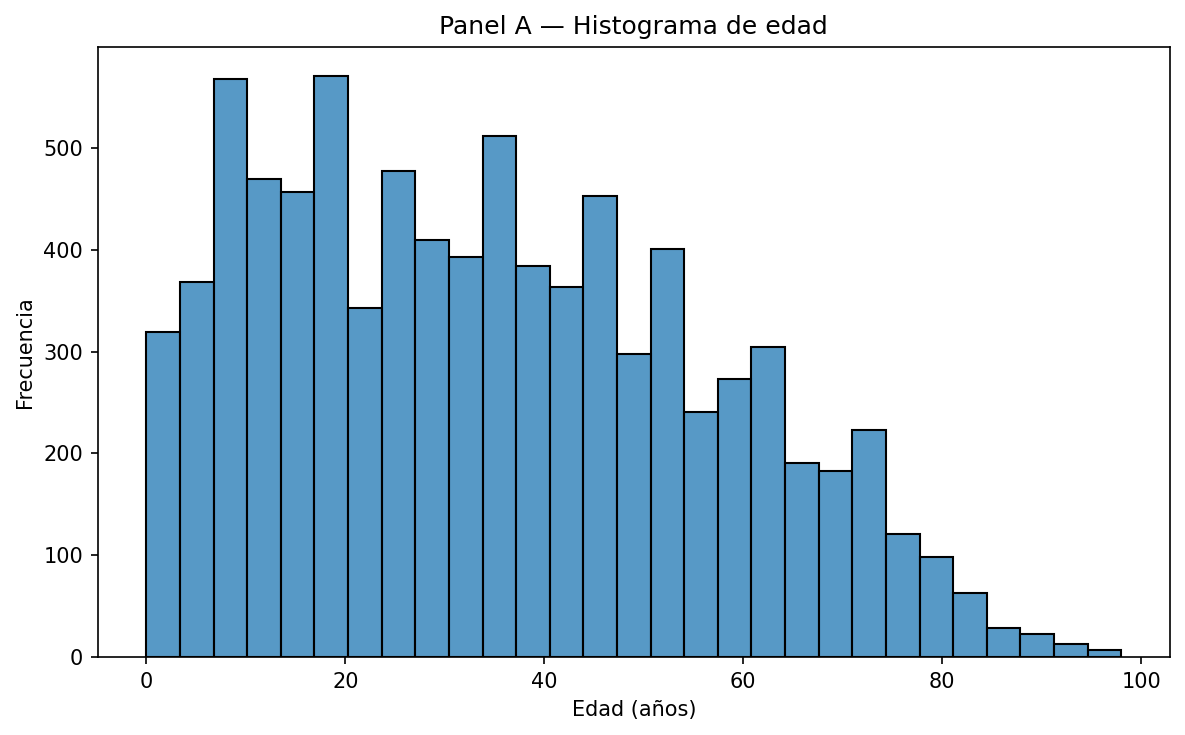

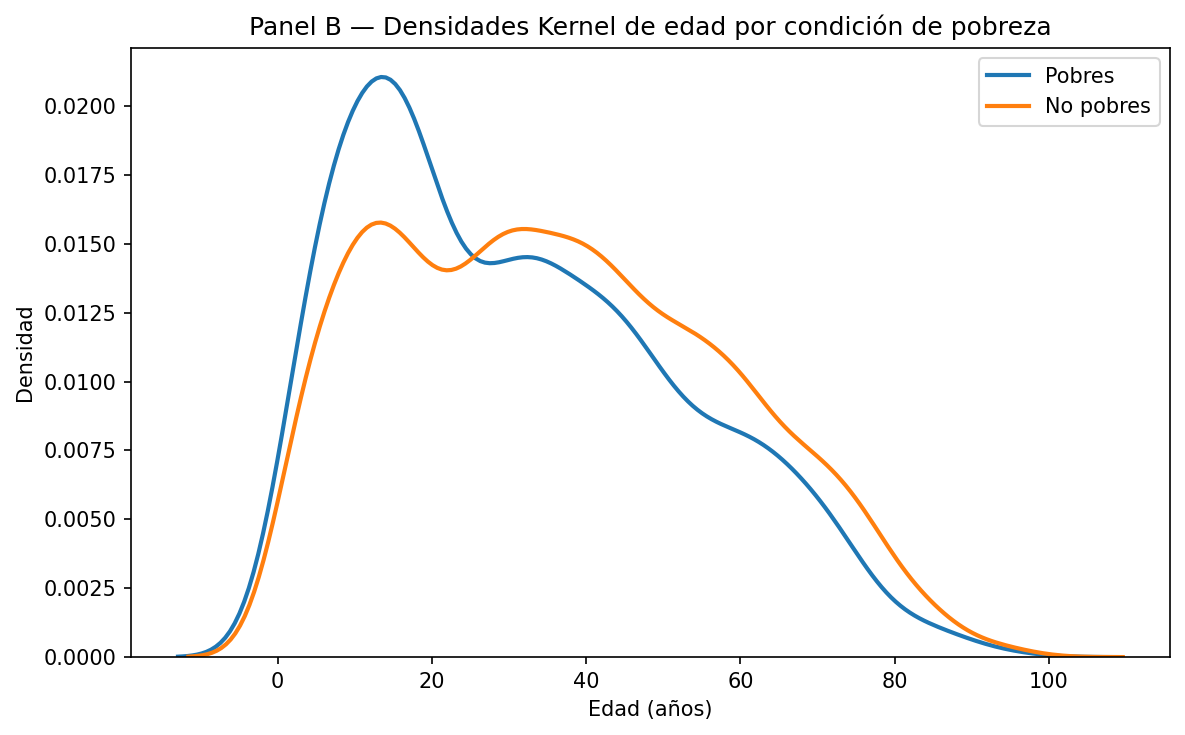

Resumen edad (total): {'n': np.int64(8555), 'media': 34.78246639392168, 'mediana': 33.0, 'p10': 8.0, 'p90': 66.0}
Resumen edad (pobres): {'n': 2788, 'media': 31.663558106169297, 'mediana': 29.0}
Resumen edad (no pobres): {'n': 5767, 'media': 36.290272238598924, 'mediana': 35.0}


In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 0) Tomo la base final ---
df = df_final.copy()

# --- 1) Detecto columnas EDAD y POBRE (por si cambió el nombre) ---
col_edad = next((c for c in df.columns if c.upper()=="EDAD" or c.upper()=="CH06"), None)
col_pobre = next((c for c in df.columns if c.upper()=="POBRE"), None)
assert col_edad is not None, "No encuentro la columna EDAD/CH06."
assert col_pobre is not None, "No encuentro la columna POBRE."

# --- 2) Limpieza mínima y creación de EDAD2 ---
# (ajustá el rango si tu recorte etario es distinto)
df.loc[~df[col_edad].between(0, 100, inclusive="both"), col_edad] = np.nan
df["EDAD2"] = (df[col_edad] ** 2).astype(float)

# --- 3) Panel A: Histograma de EDAD ---
plt.figure(figsize=(8,5), dpi=150)
sns.histplot(df[col_edad].dropna(), bins="auto", edgecolor="black")
plt.title("Panel A — Histograma de edad")
plt.xlabel("Edad (años)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("panel1A_hist_edad.png")
plt.show()

# --- 4) Panel B: Densidades (KDE) de EDAD por POBRE ---
mask = df[col_pobre].isin([0,1]) & df[col_edad].notna()
df_sub = df.loc[mask, [col_edad, col_pobre]].copy()

plt.figure(figsize=(8,5), dpi=150)
sns.kdeplot(df_sub.loc[df_sub[col_pobre]==1, col_edad], common_norm=False, linewidth=2, label="Pobres")
sns.kdeplot(df_sub.loc[df_sub[col_pobre]==0, col_edad], common_norm=False, linewidth=2, label="No pobres")
plt.title("Panel B — Densidades Kernel de edad por condición de pobreza")
plt.xlabel("Edad (años)")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.savefig("panel1B_kde_edad_pobreza.png")
plt.show()

# --- 5) Estadísticas rápidas para comentar (completá con estos valores) ---
def q(x, p): 
    return np.nanpercentile(x, p)

desc_total = {
    "n": df[col_edad].notna().sum(),
    "media": float(np.nanmean(df[col_edad])),
    "mediana": float(np.nanmedian(df[col_edad])),
    "p10": float(q(df[col_edad], 10)),
    "p90": float(q(df[col_edad], 90)),
}

desc_pob = {
    "n": int(df_sub.loc[df_sub[col_pobre]==1, col_edad].shape[0]),
    "media": float(np.nanmean(df_sub.loc[df_sub[col_pobre]==1, col_edad])),
    "mediana": float(np.nanmedian(df_sub.loc[df_sub[col_pobre]==1, col_edad])),
}

desc_npob = {
    "n": int(df_sub.loc[df_sub[col_pobre]==0, col_edad].shape[0]),
    "media": float(np.nanmean(df_sub.loc[df_sub[col_pobre]==0, col_edad])),
    "mediana": float(np.nanmedian(df_sub.loc[df_sub[col_pobre]==0, col_edad])),
}

print("Resumen edad (total):", desc_total)
print("Resumen edad (pobres):", desc_pob)
print("Resumen edad (no pobres):", desc_npob)


In [121]:
#ej 2 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# 0) Base y detección de columnas
# ---------------------------
df = df_final.copy()

col_nivel  = next((c for c in df.columns if c.upper() == "CH12"), None)   # nivel más alto alcanzado
col_final  = next((c for c in df.columns if c.upper() == "CH13"), None)   # 1=finalizó ese nivel, 2=no
col_ultimo = next((c for c in df.columns if c.upper() == "CH14"), None)   # último año aprobado en ese nivel

assert col_nivel and col_final and col_ultimo, "Faltan columnas CH12, CH13 o CH14."

# Coerción a numérico (evita strings/espacios)
df[col_nivel]  = pd.to_numeric(df[col_nivel], errors="coerce")
df[col_final]  = pd.to_numeric(df[col_final], errors="coerce")
df[col_ultimo] = pd.to_numeric(df[col_ultimo], errors="coerce")

# ---------------------------
# 1) Tabla de años por nivel si está COMPLETO (ajustable)
# ---------------------------
# Nota: esta convención es estándar para EPH: 6 (primario), 12 (secundario),
# 14 (terciario no univ, ~2 años post-secund), 17 (universitario ~5 años post-sec).
# Si tu codificación real de CH12 difiere, ajustá el mapping.
map_nivel_completo = {
    0: 0,   # sin instrucción
    1: 6,   # primario completo
    2: 12,  # secundario completo
    3: 14,  # terciario no universitario completo
    4: 17,  # universitario completo
    5: 19,  # posgrado (opcional; dejé 19 como referencia)
}

# ---------------------------
# 2) Función para calcular años de educación
# ---------------------------
def calc_educ(nivel, finalizo, ultimo):
    """
    Devuelve años de educación formal acumulados.
    nivel: CH12 (0..5), finalizo: CH13 (1=Sí, 2=No), ultimo: CH14 (año aprobado dentro del nivel).
    """
    if pd.isna(nivel):
        return np.nan

    nivel = int(nivel)  # segura coerción
    fin = int(finalizo) if pd.notna(finalizo) else None
    ult = int(ultimo) if pd.notna(ultimo) else 0

    # Si finalizó el nivel y tenemos mapping, usa el total del nivel completo
    if fin == 1 and nivel in map_nivel_completo:
        return float(map_nivel_completo[nivel])

    # Si NO finalizó, contar los años aprobados hasta donde llegó:
    # - Primario: 1..6
    # - Secundario: 6 + (1..6)
    # - Terciario no univ: 12 + (1..3)   (ajustable según codificación real de CH14)
    # - Universitario:     12 + (1..6)   (ajustable)
    if fin != 1:
        if nivel == 0:         # sin instrucción
            return 0.0
        elif nivel == 1:       # primario
            return float(np.clip(ult, 0, 6))
        elif nivel == 2:       # secundario
            return float(6 + np.clip(ult, 0, 6))
        elif nivel == 3:       # terciario no universitario
            return float(12 + np.clip(ult, 0, 3))
        elif nivel == 4:       # universitario
            return float(12 + np.clip(ult, 0, 6))
        elif nivel == 5:       # posgrado (si no finalizó, sumar sobre universitario)
            return float(17 + np.clip(ult, 0, 4))  # opcional/ilustrativo
        else:
            return np.nan

    # Si no puso en nada, devolvé NaN
    return np.nan

# ---------------------------
# 3) Construcción de 'educ'
# ---------------------------
df["educ"] = df.apply(lambda r: calc_educ(r[col_nivel], r[col_final], r[col_ultimo]), axis=1)

# Sanitizar: 0 <= educ <= 21 (evita outliers de codificación)
df.loc[df["educ"] < 0, "educ"] = 0
df.loc[df["educ"] > 21, "educ"] = 21

# ---------------------------
# 4) Estadísticas descriptivas (arreglado el KeyError)
# ---------------------------
desc = df["educ"].describe(percentiles=[0.5])  # Serie: count, mean, std, min, 50%, max
print("Estadísticos de 'educ':")
print(desc.loc[["mean","std","min","50%","max"]])

# (Opcional) guardo un dict si lo querés usar en el informe
stats_educ = {
    "mean": float(desc["mean"]),
    "sd":   float(desc["std"]),
    "min":  float(desc["min"]),
    "p50":  float(desc["50%"]),
    "max":  float(desc["max"]),
}
print("\nResumen (dict):", stats_educ)

# ---------------------------
# 5) (Opcional) Histograma exportable de 'educ'
# ---------------------------
plt.figure(figsize=(8,5), dpi=150)
plt.hist(df["educ"].dropna(), bins=range(0, 23), edgecolor="black")
plt.title("Histograma de años de educación (educ)")
plt.xlabel("Años de educación")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("panel2_hist_educ.png", dpi=300, bbox_inches="tight")
plt.close()

# Dejo la versión con 'educ' en tu df_final por si lo querés seguir usando
df_final = df


Estadísticos de 'educ':
mean    11.987928
std      4.591489
min      0.000000
50%     12.000000
max     20.000000
Name: educ, dtype: float64

Resumen (dict): {'mean': 11.987927872860636, 'sd': 4.591489284558383, 'min': 0.0, 'p50': 12.0, 'max': 20.0}


In [122]:
print(df[["CH12", "CH13","CH14", "educ"]].sample(10))


      CH12  CH13  CH14  educ
2636     2   NaN  <NA>   6.0
6739     2   1.0  <NA>  12.0
4284     4   2.0     3  15.0
2111     2   NaN  <NA>   6.0
5923     4   1.0  <NA>  17.0
7450     4   1.0  <NA>  17.0
922      2   NaN  <NA>   6.0
866      4   NaN  <NA>  12.0
8176     2   1.0  <NA>  12.0
2537     3   NaN  <NA>  12.0


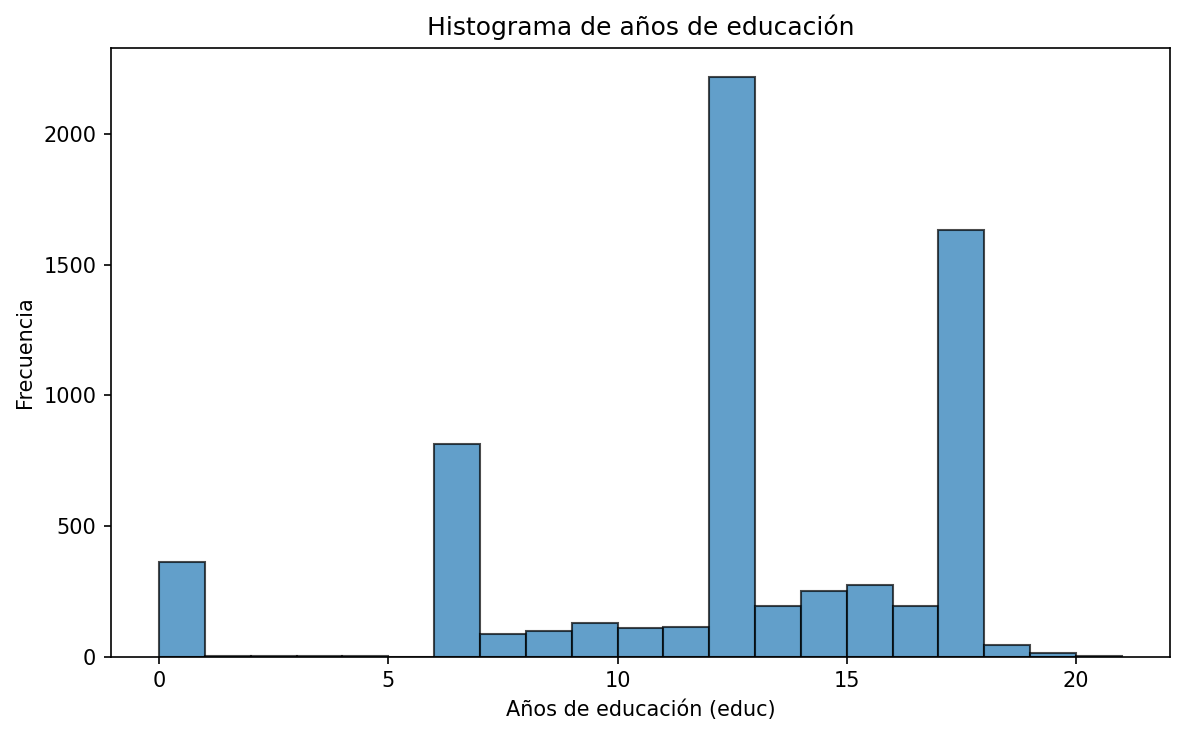

In [123]:
import matplotlib.pyplot as plt

# Histograma de años de educación
plt.figure(figsize=(8,5), dpi=150)
plt.hist(df_final["educ"].dropna(), bins=range(0, 22), edgecolor="black", alpha=0.7)
plt.title("Histograma de años de educación")
plt.xlabel("Años de educación (educ)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("panel2A_hist_educ.png", dpi=300, bbox_inches="tight")
plt.show()


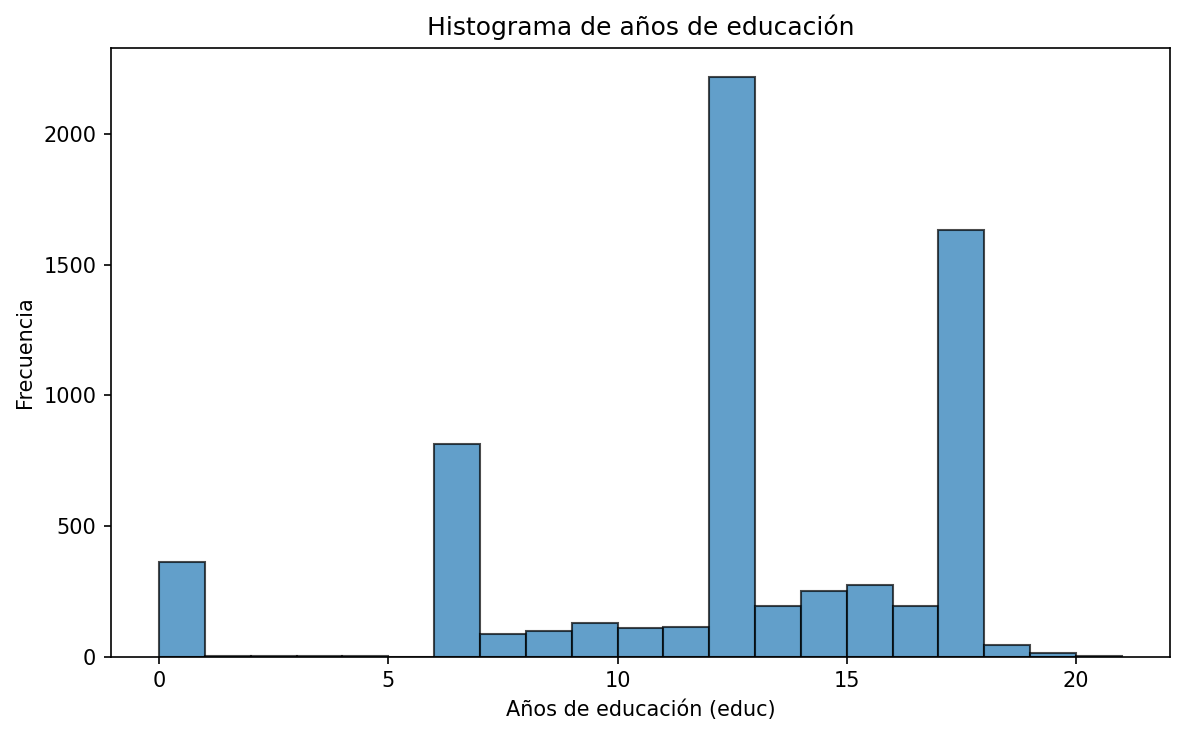

In [124]:
import matplotlib.pyplot as plt

# Histograma de años de educación con exportación
plt.figure(figsize=(8,5), dpi=150)
plt.hist(df_final["educ"].dropna(), bins=range(0, 22), edgecolor="black", alpha=0.7)
plt.title("Histograma de años de educación")
plt.xlabel("Años de educación (educ)")
plt.ylabel("Frecuencia")
plt.tight_layout()

# Exportar a archivo PNG (alta calidad)
plt.savefig("panel2A_hist_educ.png", dpi=300, bbox_inches="tight")

# Mostrar en pantalla
plt.show()

# (opcional) cerrar la figura para liberar memoria
plt.close()


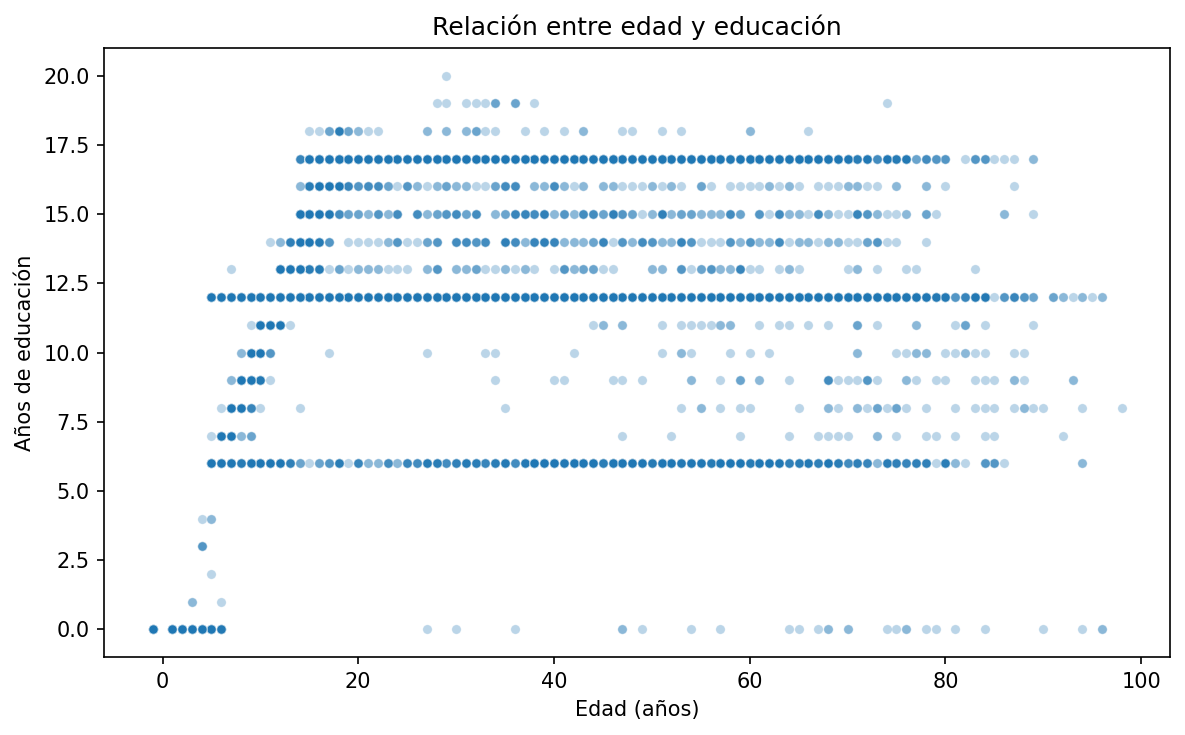

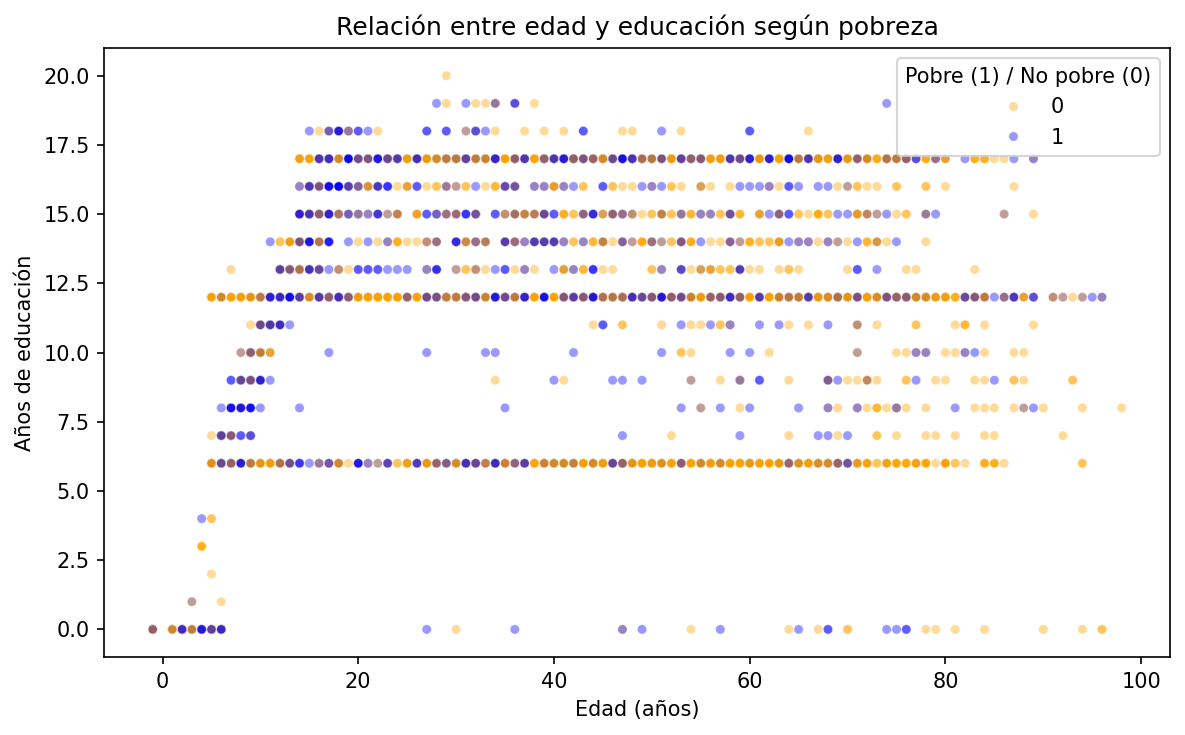

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ajustar nombre real de la columna de edad
col_edad = "CH06"   # o "EDAD" si la tenés así
col_educ = "educ"

# Scatter básico
plt.figure(figsize=(8,5), dpi=150)
sns.scatterplot(data=df_final, x=col_edad, y=col_educ, alpha=0.3, s=20)
plt.title("Relación entre edad y educación")
plt.xlabel("Edad (años)")
plt.ylabel("Años de educación")
plt.tight_layout()
plt.savefig("panel2B_scatter_edad_educ.png", dpi=300, bbox_inches="tight")
plt.show()

# Scatter coloreado por pobreza
plt.figure(figsize=(8,5), dpi=150)
sns.scatterplot(
    data=df_final, x=col_edad, y=col_educ,
    hue="POBRE", alpha=0.4, s=20,
    palette={0:"orange", 1:"blue"}
)
plt.title("Relación entre edad y educación según pobreza")
plt.xlabel("Edad (años)")
plt.ylabel("Años de educación")
plt.legend(title="Pobre (1) / No pobre (0)")
plt.tight_layout()
plt.savefig("panel2C_scatter_edad_educ_pobre.png", dpi=300, bbox_inches="tight")
plt.show()


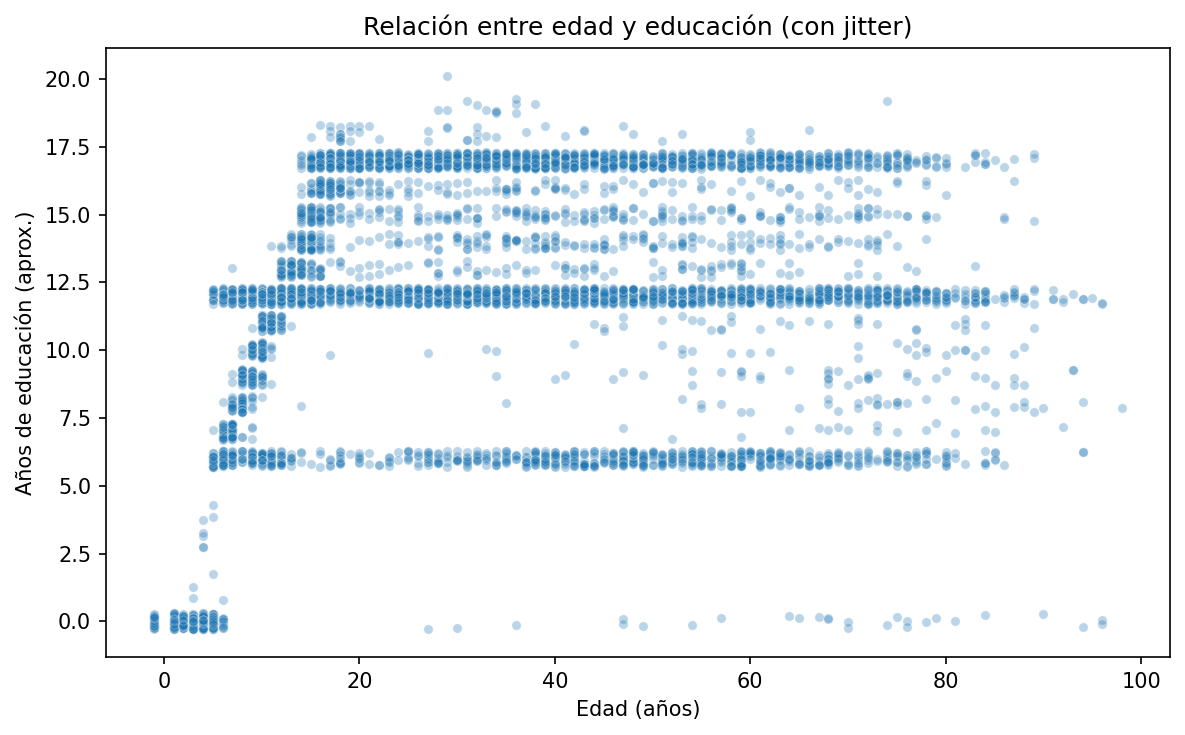

In [126]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

col_edad = "CH06"   # o "EDAD", según tu base
col_educ = "educ"

# Creamos una copia con jitter en la educación
df_jitter = df_final.copy()
np.random.seed(42)  # para reproducibilidad
df_jitter["educ_jitter"] = df_jitter[col_educ] + np.random.uniform(-0.3, 0.3, size=len(df_jitter))

plt.figure(figsize=(8,5), dpi=150)
sns.scatterplot(data=df_jitter, x=col_edad, y="educ_jitter", alpha=0.3, s=20)
plt.title("Relación entre edad y educación (con jitter)")
plt.xlabel("Edad (años)")
plt.ylabel("Años de educación (aprox.)")
plt.tight_layout()
plt.savefig("panel2B_scatter_edad_educ_jitter.png", dpi=300, bbox_inches="tight")
plt.show()


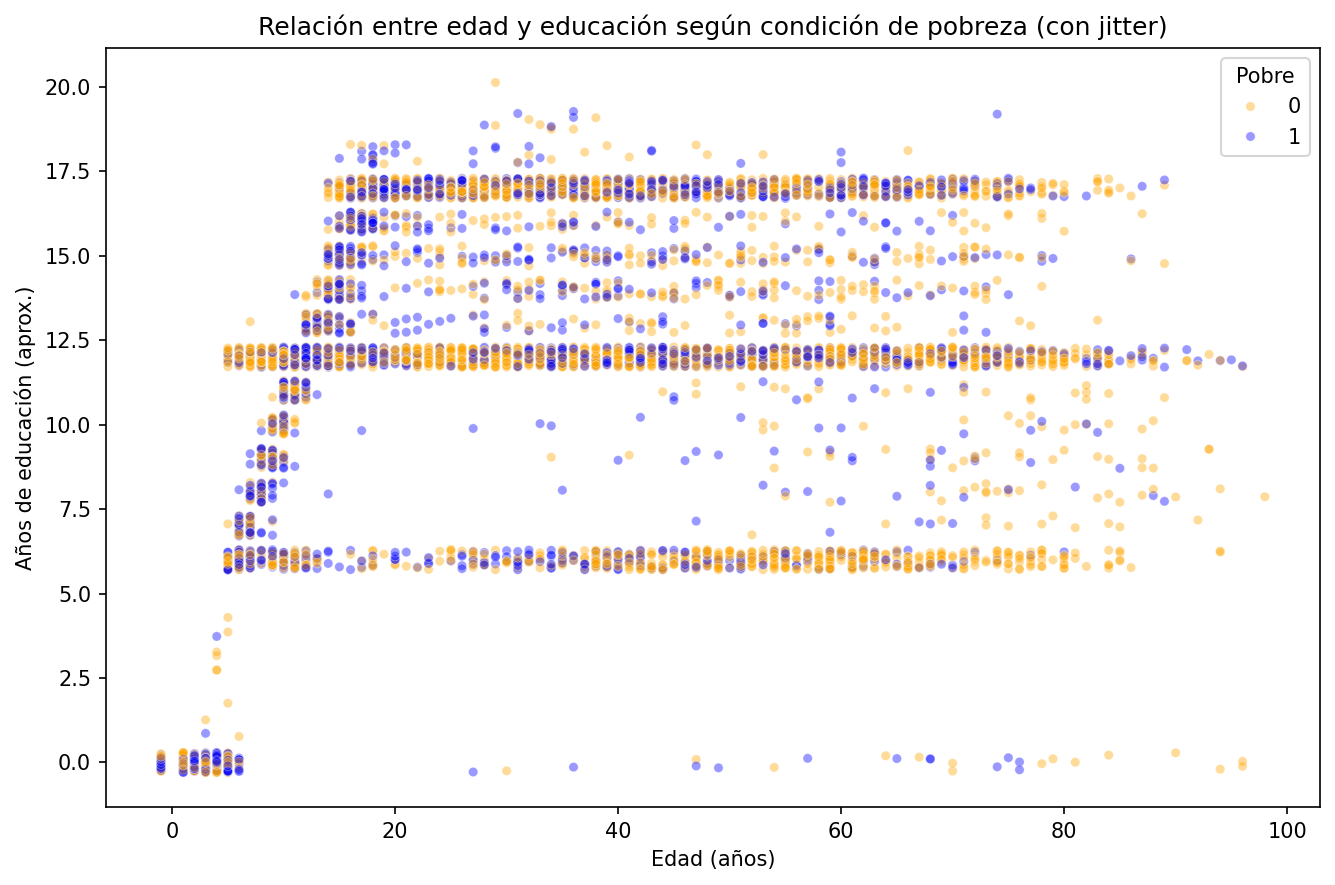

In [127]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

col_edad = "CH06"   # o "EDAD" si en tu base se llama así
col_educ = "educ"

# Creamos jitter en la variable de educación
df_jitter = df_final.copy()
np.random.seed(42)  # reproducibilidad
df_jitter["educ_jitter"] = df_jitter[col_educ] + np.random.uniform(-0.3, 0.3, size=len(df_jitter))

# Scatter con color por pobreza
plt.figure(figsize=(9,6), dpi=150)
sns.scatterplot(
    data=df_jitter,
    x=col_edad, y="educ_jitter",
    hue="POBRE", alpha=0.4, s=20,
    palette={0: "orange", 1: "blue"}  # 0=no pobre (naranja), 1=pobre (azul)
)
plt.title("Relación entre edad y educación según condición de pobreza (con jitter)")
plt.xlabel("Edad (años)")
plt.ylabel("Años de educación (aprox.)")
plt.legend(title="Pobre")
plt.tight_layout()
plt.savefig("panel2C_scatter_edad_educ_pobre_jitter.png", dpi=300, bbox_inches="tight")
plt.show()


Factor de actualización 2005→2025: 1423.8951493581799


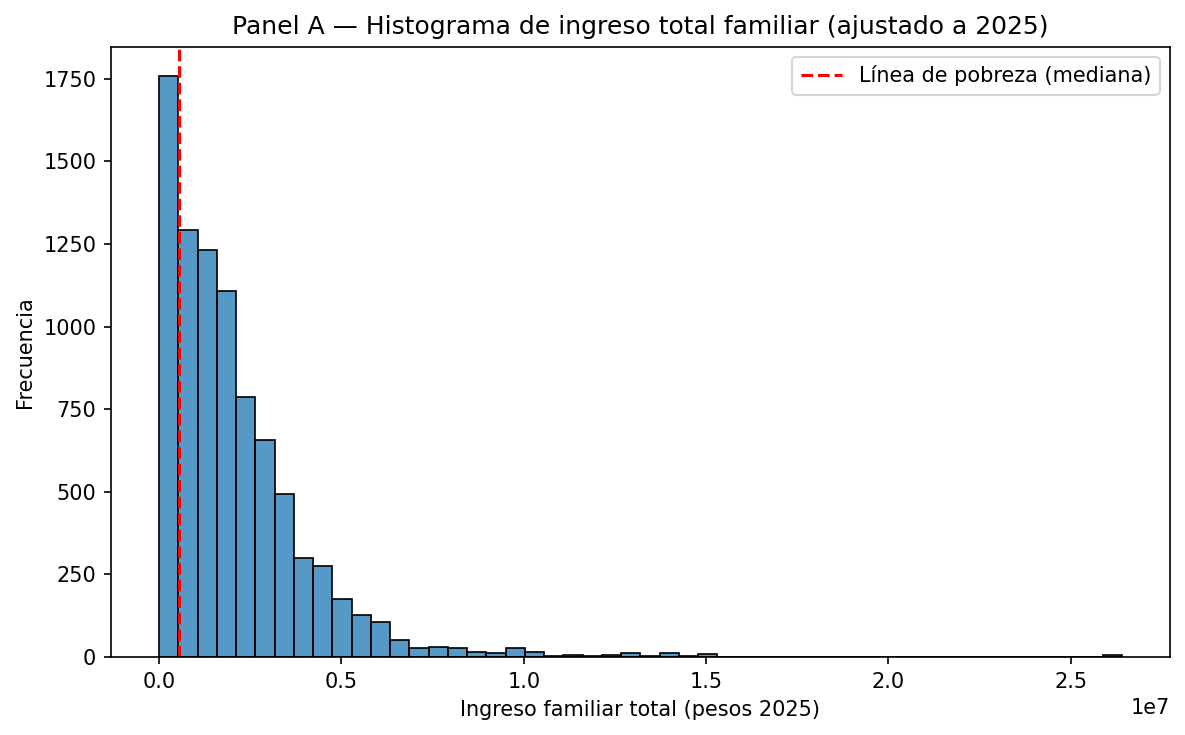

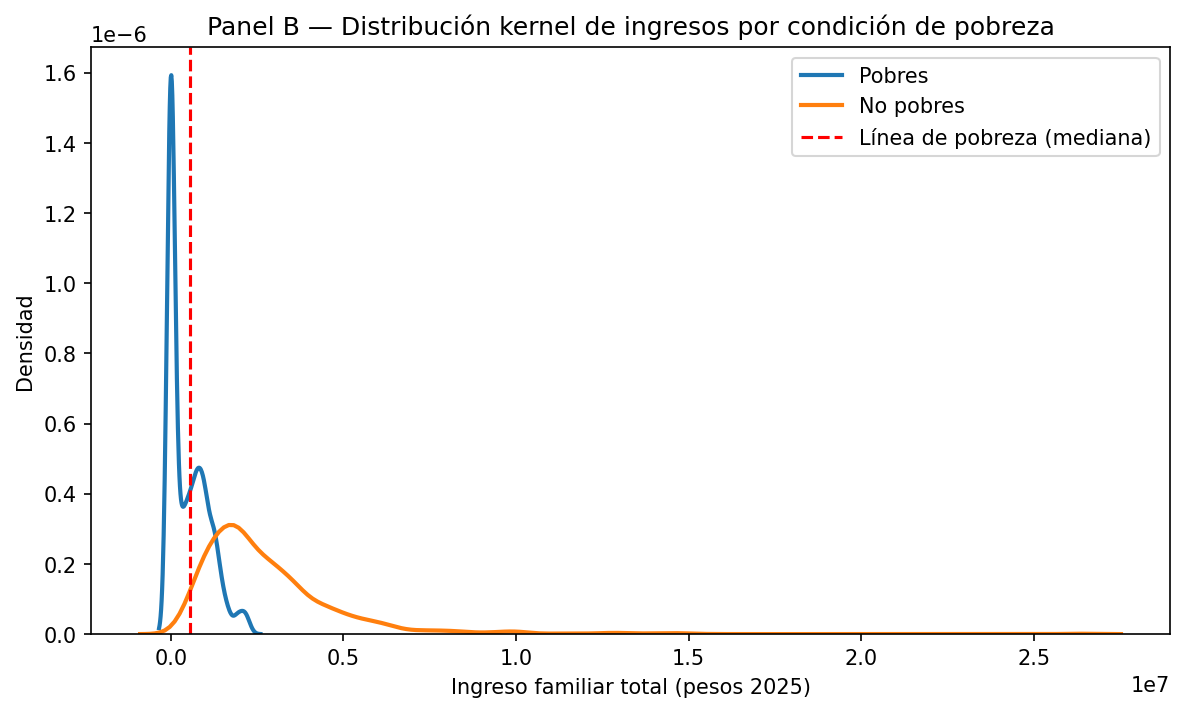

In [128]:
### ejercico 3
import matplotlib.pyplot as plt
import seaborn as sns

# --- 0) Definir columnas ---
col_itf = next((c for c in df_final.columns if "ITF" in c.upper()), None)
col_ano = next((c for c in df_final.columns if "ANO" in c.upper() or "PERIODO" in c.upper()), None)

# --- 1) Factor de actualización 2005 → 2025 ---
CBT_AE_2005 = 250.07
CBT_AE_2025 = 356073.46
factor = CBT_AE_2025 / CBT_AE_2005
print("Factor de actualización 2005→2025:", factor)

# --- 2) Crear columna ajustada ---
df = df_final.copy()
df["ITF_ajustado"] = df[col_itf]
df.loc[df[col_ano]==2005, "ITF_ajustado"] = df.loc[df[col_ano]==2005, col_itf] * factor

# --- 3) Panel A: Histograma ---
plt.figure(figsize=(8,5), dpi=150)
sns.histplot(df["ITF_ajustado"].dropna(), bins=50, edgecolor="black")
plt.axvline(df["INGRESO_NECESARIO"].median(), color="red", linestyle="--", label="Línea de pobreza (mediana)")
plt.title("Panel A — Histograma de ingreso total familiar (ajustado a 2025)")
plt.xlabel("Ingreso familiar total (pesos 2025)")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.savefig("panel3A_hist_itf.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 4) Panel B: Densidades kernel (pobres vs no pobres) ---
plt.figure(figsize=(8,5), dpi=150)
sns.kdeplot(df.loc[df["POBRE"]==1, "ITF_ajustado"], label="Pobres", linewidth=2)
sns.kdeplot(df.loc[df["POBRE"]==0, "ITF_ajustado"], label="No pobres", linewidth=2)
plt.axvline(df["INGRESO_NECESARIO"].median(), color="red", linestyle="--", label="Línea de pobreza (mediana)")
plt.title("Panel B — Distribución kernel de ingresos por condición de pobreza")
plt.xlabel("Ingreso familiar total (pesos 2025)")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.savefig("panel3B_kde_itf.png", dpi=300, bbox_inches="tight")
plt.show()


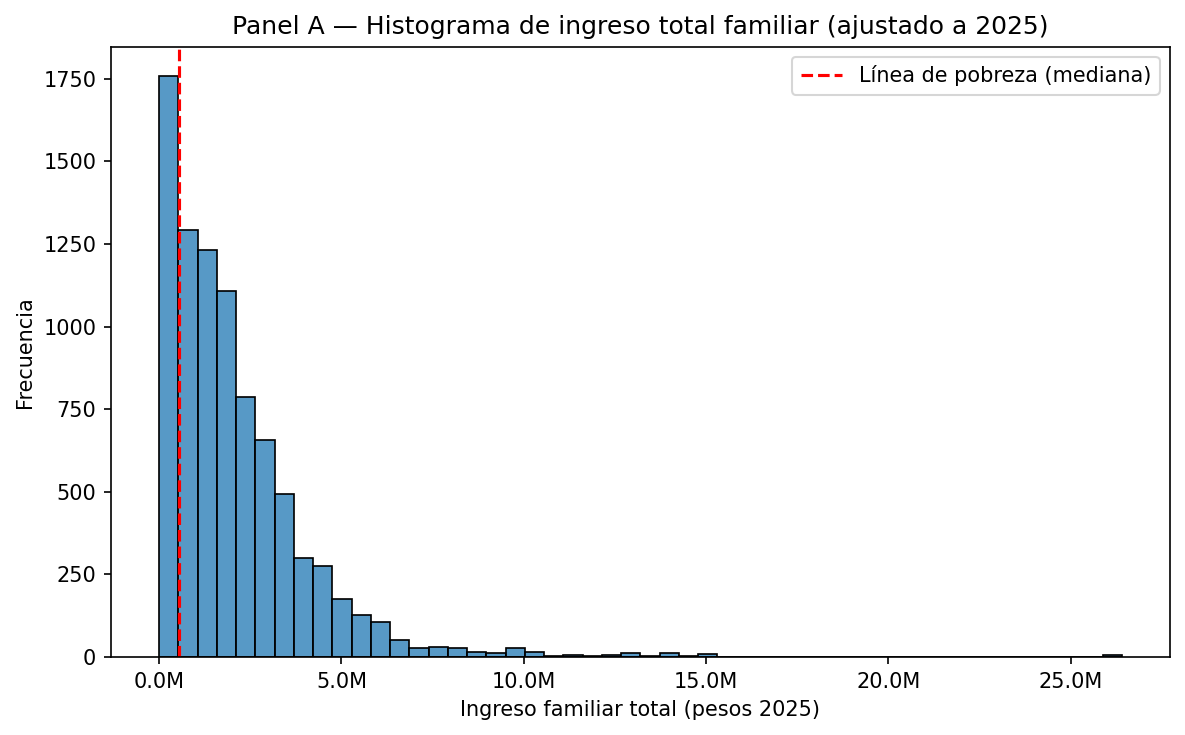

In [129]:
import matplotlib.ticker as mtick

plt.figure(figsize=(8,5), dpi=150)
sns.histplot(df["ITF_ajustado"].dropna(), bins=50, edgecolor="black")
plt.axvline(df["INGRESO_NECESARIO"].median(), color="red", linestyle="--", label="Línea de pobreza (mediana)")
plt.title("Panel A — Histograma de ingreso total familiar (ajustado a 2025)")
plt.xlabel("Ingreso familiar total (pesos 2025)")
plt.ylabel("Frecuencia")

# Opción 1: mostrar en millones
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x*1e-6:.1f}M'))

plt.legend()
plt.tight_layout()
plt.savefig("panel3A_hist_itf_millones.png", dpi=300, bbox_inches="tight")
plt.show()


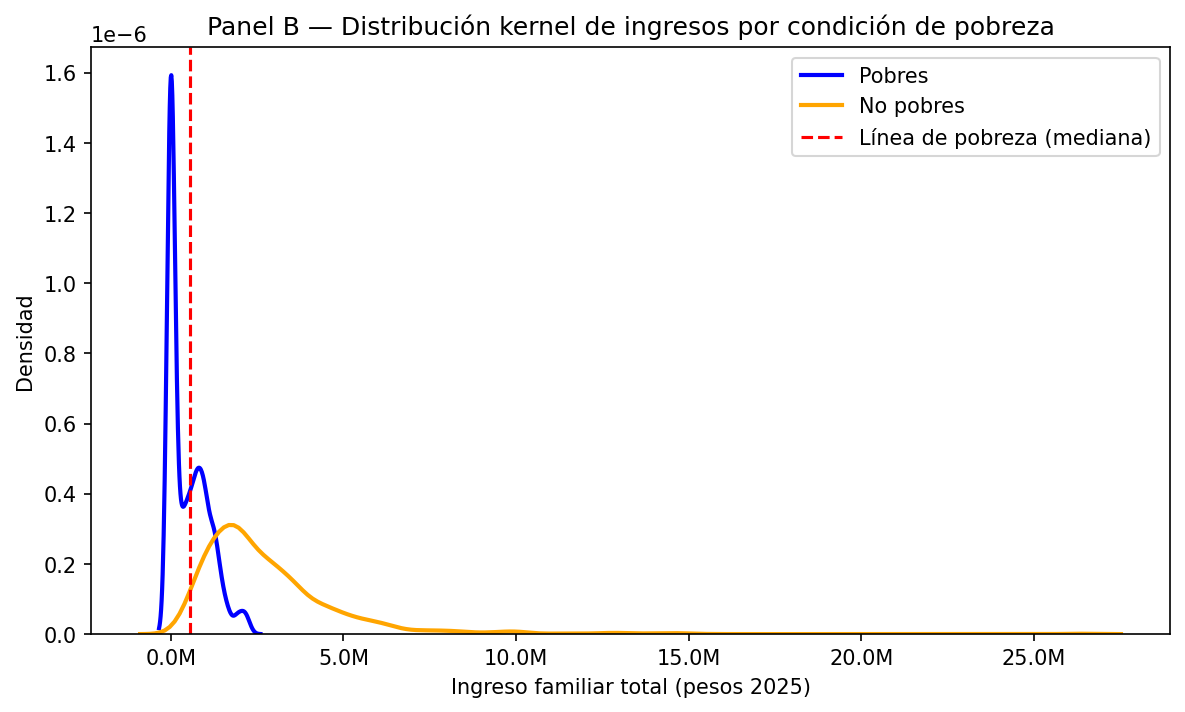

In [130]:
import seaborn as sns
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt

# Panel B: Densidades de ingresos por pobreza
plt.figure(figsize=(8,5), dpi=150)
sns.kdeplot(df.loc[df["POBRE"]==1, "ITF_ajustado"], label="Pobres", linewidth=2, color="blue")
sns.kdeplot(df.loc[df["POBRE"]==0, "ITF_ajustado"], label="No pobres", linewidth=2, color="orange")

# Línea de pobreza (mediana)
plt.axvline(df["INGRESO_NECESARIO"].median(), color="red", linestyle="--", label="Línea de pobreza (mediana)")

plt.title("Panel B — Distribución kernel de ingresos por condición de pobreza")
plt.xlabel("Ingreso familiar total (pesos 2025)")
plt.ylabel("Densidad")

# Mostrar en millones en el eje X
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x*1e-6:.1f}M'))

plt.legend()
plt.tight_layout()
plt.savefig("panel3B_kde_itf_pobreza.png", dpi=300, bbox_inches="tight")
plt.show()


In [131]:
# Resumen de ingresos por condición de pobreza
resumen_itf = df.groupby("POBRE")["ITF_ajustado"].agg(["count","mean","median"])
resumen_itf = resumen_itf.rename(index={0:"No pobres", 1:"Pobres"})
print(resumen_itf)

# Si querés verlo en millones de pesos para que sea más legible:
resumen_itf_millones = resumen_itf.copy()
resumen_itf_millones[["mean","median"]] = resumen_itf_millones[["mean","median"]] / 1e6
print("\nEn millones de pesos 2025:")
print(resumen_itf_millones)


           count          mean        median
POBRE                                       
No pobres   5785  2.804730e+06  2.278232e+06
Pobres      2803  4.876396e+05  2.900000e+05

En millones de pesos 2025:
           count     mean    median
POBRE                              
No pobres   5785  2.80473  2.278232
Pobres      2803  0.48764  0.290000


In [132]:
import pandas as pd
import numpy as np

df = df_final.copy()

# --- 0) Identificar columnas ---
col_pp3e = next((c for c in df.columns if c.upper()=="PP3E_TOT"), None)  # horas ocupación principal
col_pp3f = next((c for c in df.columns if c.upper()=="PP3F_TOT"), None)  # horas otras ocupaciones
col_rol  = next((c for c in df.columns if "ROL" in c.upper() or "CH03" in c.upper()), None)

assert col_pp3e and col_pp3f and col_rol, "Faltan columnas de horas o rol del hogar."

# --- 1) Crear variable horastrab ---
df["horastrab"] = df[col_pp3e].fillna(0) + df[col_pp3f].fillna(0)

# --- 2) Filtrar solo jefes de hogar ---
df_jefes = df[df[col_rol]==1].copy()

# --- 3) Estadísticas descriptivas ---
desc = df_jefes["horastrab"].describe(percentiles=[0.5])
stats_horas = {
    "mean": float(desc["mean"]),
    "sd":   float(df_jefes["horastrab"].std()),
    "min":  float(desc["min"]),
    "p50":  float(desc["50%"]),
    "max":  float(desc["max"]),
}
print("Estadísticos de horastrab (jefes de hogar):")
print(stats_horas)


Estadísticos de horastrab (jefes de hogar):
{'mean': 26.49308300395257, 'sd': 25.049071146830475, 'min': 0.0, 'p50': 30.0, 'max': 126.0}


In [133]:
df_jefes.sample(10)

,CODUSU,NRO_HOGAR,COMPONENTE,H15,ANO4,TRIMESTRE,REGION,MAS_500,AGLOMERADO,PONDERA,...,P_ADECCF,AE_PERS,HOGAR_ID,PERIODO,AE_HOGAR,CBT_AE_VAL,INGRESO_NECESARIO,POBRE,educ,horastrab
493,220306,1,1,Sí,2005,1,44,N,9,197.0,...,NaN,0.74,220306_1,2005,4.55,250.07,1.137818e+03,0,NaN,98.0
3673,TQRMNORRSHMNKTCDEOJAH00878097,1,1,1,2025,1,44,N,93,130.0,...,NaN,0.74,TQRMNORRSHMNKTCDEOJAH00878097_1,2025,2.99,356073.46,1.064660e+06,1,NaN,48.0
8232,TQRMNOPWRHKNKQCDEIHJF00858986,1,1,1,2025,1,44,N,31,132.0,...,8.0,1.00,TQRMNOPWRHKNKQCDEIHJF00858986_1,2025,1.00,356073.46,3.560735e+05,0,17.0,35.0
3366,TQRMNOTPXHMOKMCDEFPCH00877890,1,1,1,2025,1,44,N,9,235.0,...,NaN,1.00,TQRMNOTPXHMOKMCDEFPCH00877890_1,2025,3.29,356073.46,1.171482e+06,1,17.0,56.0
6149,TQRMNQPYUHLOLLCDEGNFJ00853264,1,1,1,2025,1,44,N,17,554.0,...,10.0,0.74,TQRMNQPYUHLOLLCDEGNFJ00853264_1,2025,0.74,356073.46,2.634944e+05,0,NaN,0.0
8161,TQRMNOPRWHLOKRCDEOHCH00856131,1,1,1,2025,1,44,N,91,363.0,...,6.0,1.00,TQRMNOPRWHLOKRCDEOHCH00856131_1,2025,1.74,356073.46,6.195678e+05,0,15.0,48.0
8176,TQRMNOQXQHKMKPCDEOJAH00860142,1,1,1,2025,1,44,N,93,112.0,...,10.0,0.64,TQRMNOQXQHKMKPCDEOJAH00860142_1,2025,1.64,356073.46,5.839605e+05,0,12.0,0.0
3649,TQRMNORSYHKOLQCDEGNFJ00857361,1,1,1,2025,1,44,N,17,182.0,...,9.0,0.74,TQRMNORSYHKOLQCDEGNFJ00857361_1,2025,1.74,356073.46,6.195678e+05,0,NaN,25.0
7459,TQRMNOPXVHLMKNCDEIHJF00873200,1,1,1,2025,1,44,N,31,52.0,...,9.0,0.74,TQRMNOPXVHLMKNCDEIHJF00873200_1,2025,0.74,356073.46,2.634944e+05,0,NaN,35.0
5423,TQRMNOQPSHJNKQCDEOJAH00875688,1,1,1,2025,1,44,N,93,62.0,...,7.0,0.74,TQRMNOQPSHJNKQCDEOJAH00875688_1,2025,0.74,356073.46,2.634944e+05,0,12.0,20.0


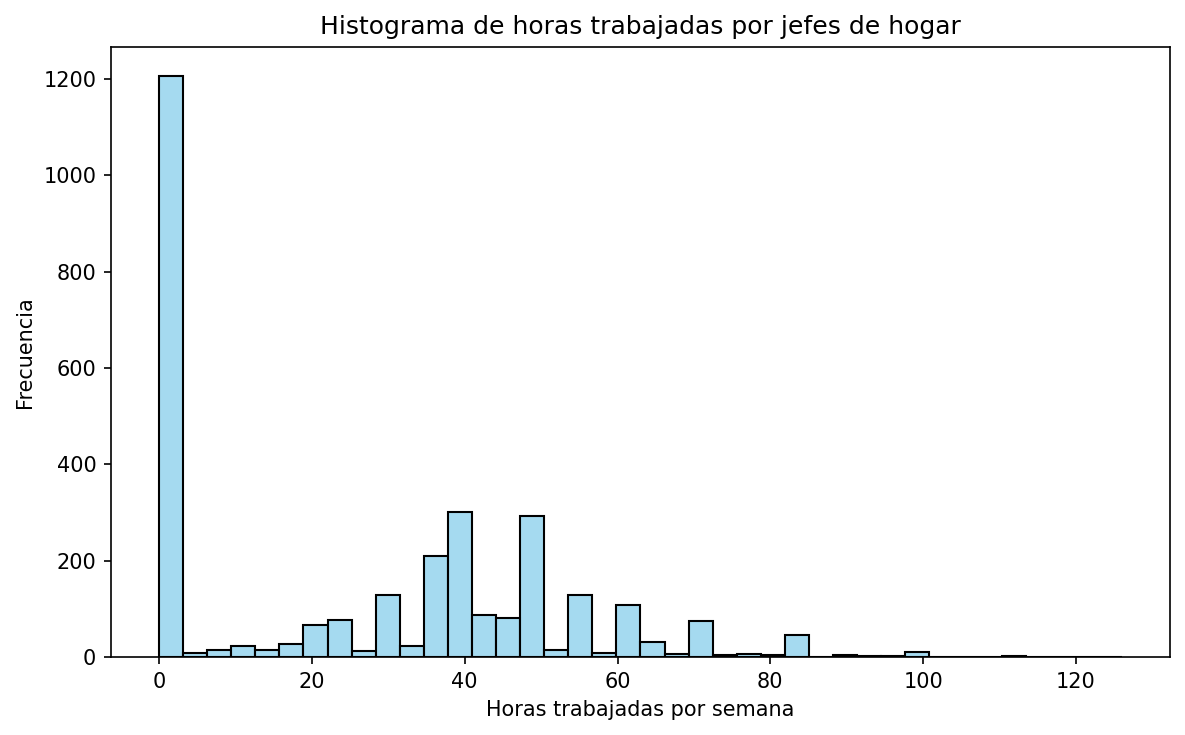

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma de horas trabajadas de jefes de hogar
plt.figure(figsize=(8,5), dpi=150)
sns.histplot(df_jefes["horastrab"].dropna(), bins=40, edgecolor="black", color="skyblue")

plt.title("Histograma de horas trabajadas por jefes de hogar")
plt.xlabel("Horas trabajadas por semana")
plt.ylabel("Frecuencia")
plt.tight_layout()

# Exportar en alta calidad
plt.savefig("panel4_hist_horastrab.png", dpi=300, bbox_inches="tight")
plt.show()


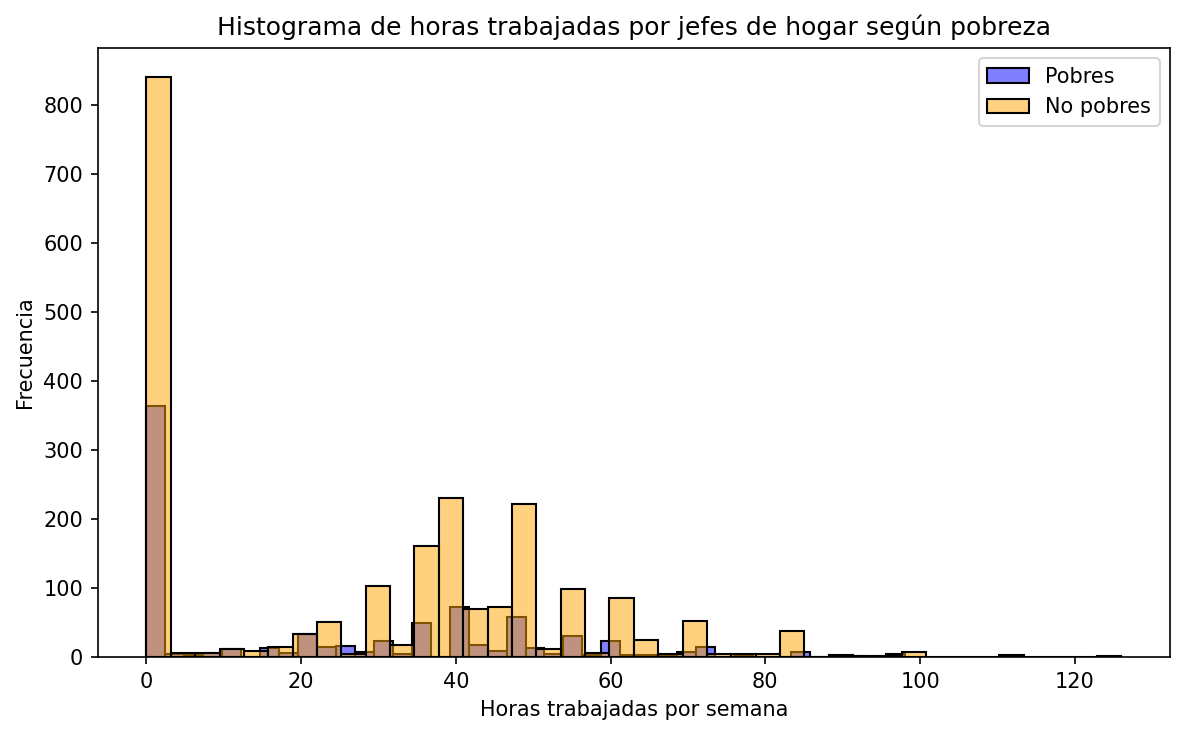

In [135]:
plt.figure(figsize=(8,5), dpi=150)
sns.histplot(df_jefes[df_jefes["POBRE"]==1]["horastrab"], 
             bins=40, color="blue", label="Pobres", alpha=0.5)
sns.histplot(df_jefes[df_jefes["POBRE"]==0]["horastrab"], 
             bins=40, color="orange", label="No pobres", alpha=0.5)

plt.title("Histograma de horas trabajadas por jefes de hogar según pobreza")
plt.xlabel("Horas trabajadas por semana")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.savefig("panel4_hist_horastrab_pobreza.png", dpi=300, bbox_inches="tight")
plt.show()


In [136]:
df.shape

(8588, 253)

In [137]:
# --- elegir base y columna automáticamente ---
df_base = df_final if 'df_final' in locals() else df
col_pobre = 'POBRE' if 'POBRE' in df_base.columns else 'pobre'

# --- conteo de NAs por año ---
res = (df_base
       .assign(_isna = df_base[col_pobre].isna())
       .groupby('ANO4')['_isna']
       .agg(n_NA='sum', n_total='size'))
res['% NA'] = (res['n_NA'] / res['n_total'] * 100).round(1)
res


,n_NA,n_total,% NA
ANO4,,,
2005,0,3229,0.0
2025,0,5359,0.0


In [138]:
df_base.sample(20)

,CODUSU,NRO_HOGAR,COMPONENTE,H15,ANO4,TRIMESTRE,REGION,MAS_500,AGLOMERADO,PONDERA,...,P_IDECCF,P_ADECCF,AE_PERS,HOGAR_ID,PERIODO,AE_HOGAR,CBT_AE_VAL,INGRESO_NECESARIO,POBRE,educ
5797,TQRMNOPWWHLOKMCDEHGHJ00853626,1,3,1,2025,1,44,N,20,437.0,...,NaN,NaN,1.06,TQRMNOPWWHLOKMCDEHGHJ00853626_1,2025,4.81,356073.46,1.712713e+06,1,NaN
8240,TQRMNOSPSHJNLLCDEFPCH00875224,1,2,1,2025,1,44,N,9,158.0,...,9.0,8.0,0.64,TQRMNOSPSHJNLLCDEFPCH00875224_1,2025,4.20,356073.46,1.495509e+06,0,12.0
6880,TQRMNORQPHLMKSCDEOJAH00856923,1,3,1,2025,1,44,N,93,92.0,...,5.0,4.0,0.74,TQRMNORQPHLMKSCDEOJAH00856923_1,2025,4.23,356073.46,1.506191e+06,0,12.0
3215,287909,1,1,Sí,2005,1,44,N,31,149.0,...,NaN,NaN,1.00,287909_1,2005,1.74,250.07,4.351218e+02,0,6.0
2043,209546,1,2,Sí,2005,1,44,N,20,68.0,...,NaN,NaN,0.74,209546_1,2005,4.01,250.07,1.002781e+03,0,6.0
5147,TQRMNORRTHJOKTCDEIHJF00879371,1,2,1,2025,1,44,N,31,85.0,...,6.0,4.0,0.82,TQRMNORRTHJOKTCDEIHJF00879371_1,2025,1.46,356073.46,5.198673e+05,0,12.0
5399,TQRMNOSPPHKMLLCDEOJAH00863281,1,1,1,2025,1,44,N,93,113.0,...,7.0,6.0,1.00,TQRMNOSPPHKMLLCDEOJAH00863281_1,2025,2.89,356073.46,1.029052e+06,0,NaN
3709,TQRMNOSUSHLOKUCDEGNFJ00853349,1,1,1,2025,1,44,N,17,253.0,...,2.0,1.0,1.00,TQRMNOSUSHLOKUCDEGNFJ00853349_1,2025,2.37,356073.46,8.438941e+05,1,12.0
3164,279299,1,4,Sí,2005,1,44,N,31,115.0,...,NaN,NaN,0.79,279299_1,2005,3.58,250.07,8.952506e+02,0,12.0
4525,TQRMNORWSHMOKSCDEGNFJ00878567,1,7,1,2025,1,44,N,17,252.0,...,NaN,NaN,0.74,TQRMNORWSHMOKSCDEGNFJ00878567_1,2025,5.46,356073.46,1.944161e+06,1,NaN


In [139]:
for col in df_base.columns:
    print(col)


CODUSU
NRO_HOGAR
COMPONENTE
H15
ANO4
TRIMESTRE
REGION
MAS_500
AGLOMERADO
PONDERA
CH03
CH04
CH06
CH07
CH08
CH09
CH10
CH11
CH12
CH13
CH14
CH15
CH15_COD
CH16
CH16_COD
NIVEL_ED
ESTADO
CAT_OCUP
CAT_INAC
PP02C1
PP02C2
PP02C3
PP02C4
PP02C5
PP02C6
PP02C7
PP02C8
PP02E
PP02H
PP02I
PP03C
PP03D
PP3E_TOT
PP3F_TOT
PP03G
PP03H
PP03I
PP03J
INTENSI
PP04A
PP04B_COD
PP04B1
PP04B2
PP04B3_MES
PP04B3_ANO
PP04B3_DIA
PP04C
PP04C99
PP04D_COD
PP04G
PP05B2_MES
PP05B2_ANO
PP05B2_DIA
PP05C_1
PP05C_2
PP05C_3
PP05E
PP05F
PP05H
PP06A
PP06C
PP06D
PP06E
PP06H
PP07A
PP07C
PP07D
PP07E
PP07F1
PP07F2
PP07F3
PP07F4
PP07F5
PP07G1
PP07G2
PP07G3
PP07G4
PP07G_59
PP07H
PP07I
PP07J
PP07K
PP08D1
PP08D4
PP08F1
PP08F2
PP08J1
PP08J2
PP08J3
PP09A
PP09A_ESP
PP09B
PP09C
PP09C_ESP
PP10A
PP10C
PP10D
PP10E
PP11A
PP11B_COD
PP11B1
PP11B2_MES
PP11B2_ANO
PP11B2_DIA
PP11C
PP11C99
PP11D_COD
PP11G_ANO
PP11G_MES
PP11G_DIA
PP11L
PP11L1
PP11M
PP11N
PP11O
PP11P
PP11Q
PP11R
PP11S
PP11T
P21
DECOCUR
IDECOCUR
RDECOCUR
GDECOCUR
PDECOCUR
ADECOCUR
TOT_P12
P

In [140]:
# 1. Renombrar CH06 -> EDAD
df_base = df_base.rename(columns={'CH06': 'EDAD'})

# 2. Crear EDAD2 = EDAD ** 2
df_base['EDAD2'] = df_base['EDAD'] ** 2

# 3. Crear horastrab = PP3E_TOT + PP3F_TOT
df_base['horastrab'] = df_base['PP3E_TOT'] + df_base['PP3F_TOT']

In [141]:
df_base.columns = df_base.columns.str.upper()


In [142]:
# 1. Crear IX_TOT a partir de CODUSU
df_base['IX_TOT'] = df_base.groupby('CODUSU')['CODUSU'].transform('size')

# 2. Seleccionar solo las variables que pide la consigna
df_parte2 = df_base[['EDAD', 'EDAD2', 'HORASTRAB', 'EDUC', 'ITF', 'IX_TOT', 'CODUSU']]


In [143]:
df_parte2.sample(20)

,EDAD,EDAD2,HORASTRAB,EDUC,ITF,IX_TOT,CODUSU
1178,63,3969,48.0,12.0,300.0,3,193036
3690,60,3600,NaN,NaN,0.0,1,TQRMNORUVHJMKNCDEOJAH00877953
1496,9,81,0.0,6.0,2490.0,4,256647
8144,55,3025,30.0,16.0,1820000.0,4,TQRMNOPUPHLMKNCDEHGHJ00853671
967,14,196,0.0,12.0,500.0,8,149895
3146,31,961,48.0,NaN,3200.0,2,277857
3887,55,3025,25.0,17.0,0.0,1,TQRMNOQVYHMOKMCDEFPCH00878501
5055,59,3481,NaN,17.0,4000000.0,4,TQRMNOPTPHMMKPCDEIHJF00879368
6937,54,2916,NaN,NaN,2150000.0,2,TQRMNOPSQHMMKRCDEOJAH00880562
4450,6,36,NaN,0.0,1275000.0,5,TQRMNOSTVHLOKPCDEGNFJ00853335


               EDAD     EDAD2  HORASTRAB      EDUC       ITF    IX_TOT
EDAD       1.000000  0.959671   0.282217  0.213293  0.061106 -0.400051
EDAD2      0.959671  1.000000   0.161374  0.089655  0.046432 -0.383098
HORASTRAB  0.282217  0.161374   1.000000  0.313655  0.222488 -0.212903
EDUC       0.213293  0.089655   0.313655  1.000000  0.177634 -0.138086
ITF        0.061106  0.046432   0.222488  0.177634  1.000000 -0.071670
IX_TOT    -0.400051 -0.383098  -0.212903 -0.138086 -0.071670  1.000000


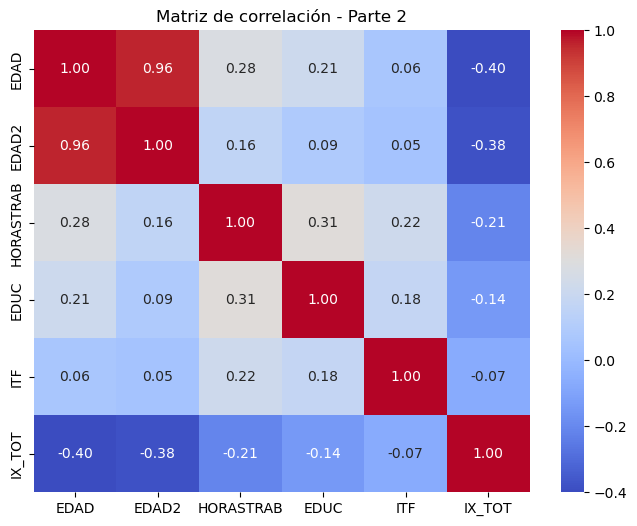

In [144]:
#PARTE 2

#1
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Seleccionar todas las columnas excepto CODUSU
df_corr = df_parte2.drop(columns=['CODUSU'])

# 2. Calcular matriz de correlación
corr_matrix = df_corr.corr()

# 3. Mostrar matriz en pantalla
print(corr_matrix)

# 4. Visualizar con un mapa de calor
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Matriz de correlación - Parte 2")
plt.show()


In [145]:
#1
#solo para guardar
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Matriz de correlación - Parte 2")
plt.tight_layout()
plt.savefig("heatmap_correlacion.png", dpi=300)
plt.close()


Observaciones usadas: 3988

Varianza explicada:
PC1    0.397
PC2    0.256
dtype: float64

Cargas (loadings):
             PC1    PC2
EDAD       0.588 -0.277
EDAD2      0.550 -0.373
EDUC       0.164  0.635
ITF        0.252  0.493
IX_TOT    -0.380 -0.036
HORASTRAB  0.342  0.369


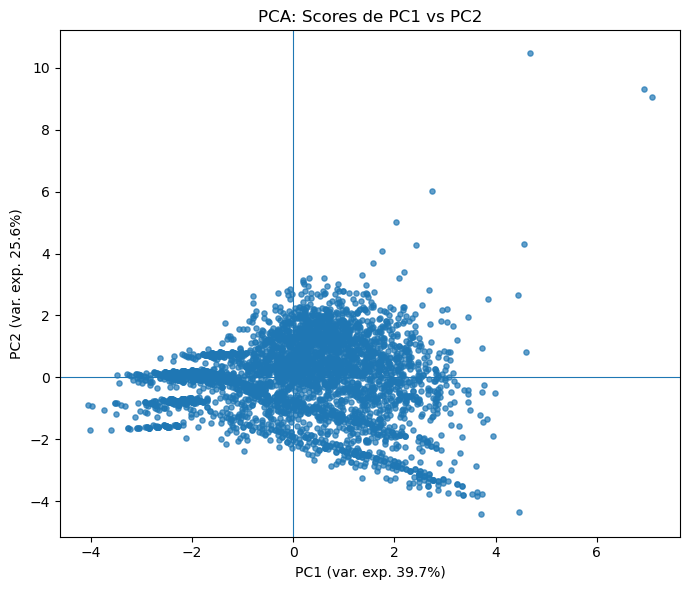

<Figure size 640x480 with 0 Axes>

In [146]:
#2
# --- PCA con estandarización sobre 6 variables (EDAD, EDAD2, EDUC, ITF, IX_TOT/IX_Tot, HORASTRAB) ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# >>> 1) Elegí tu DataFrame aquí
df_region =  df_parte2.copy()   # <- hacemos una copy por las dudas y q no influya en el original

# >>> 2) Alinear nombre de miembros del hogar (2005 IX_TOT, 2025 IX_Tot) a IX_TOT
if 'IX_Tot' in df_region.columns and 'IX_TOT' not in df_region.columns:
    df_region = df_region.rename(columns={'IX_Tot':'IX_TOT'})

vars_pca = ['EDAD','EDAD2','EDUC','ITF','IX_TOT','HORASTRAB'] #son las 6 q pide
faltan = [v for v in vars_pca if v not in df_region.columns]
assert len(faltan)==0, f"Faltan columnas en el DF: {faltan}"

# >>> 3) Limpieza básica
X = df_region[vars_pca].replace([np.inf, -np.inf], np.nan).dropna(axis=0, how='any') #Elimino valores infinitos y filas con NaN en esas variables.
print(f"Observaciones usadas: {len(X)}")

# >>> 4) Estandarizar
scaler = StandardScaler()
Z = scaler.fit_transform(X) #cada variable queda con media 0 y desviación estándar 1.
#z es la varibale estandarizada

# >>> 5) PCA
pca = PCA(n_components=2, random_state=42)
scores = pca.fit_transform(Z)   # índices / coordenadas PC1-PC2
expl_var = pca.explained_variance_ratio_

# >>> 6) Cargas (loadings)
loadings = pd.DataFrame(pca.components_.T,
                        index=vars_pca,
                        columns=['PC1','PC2'])
print("\nVarianza explicada:")
print(pd.Series(expl_var, index=['PC1','PC2']).round(3))

print("\nCargas (loadings):")
print(loadings.round(3)) #cuánto pesa cada variable en cada componente.
#scores[:,0] es PC1, scores[:,1] es PC2.

# >>> 7) Gráfico de dispersión de scores (PC1 vs PC2)
plt.figure(figsize=(7,6))
plt.scatter(scores[:,0], scores[:,1], s=14, alpha=0.7) #scatterplot
plt.axhline(0, lw=0.8); plt.axvline(0, lw=0.8) #Agrego líneas horizontales/verticales en cero para ubicar los cuadrantes.
plt.xlabel(f'PC1 (var. exp. {expl_var[0]:.1%})')
plt.ylabel(f'PC2 (var. exp. {expl_var[1]:.1%})')
plt.title('PCA: Scores de PC1 vs PC2')
plt.tight_layout()
plt.show()

plt.savefig("pca_scores.png", dpi=300) 

NameError: name 'x_loadings' is not defined

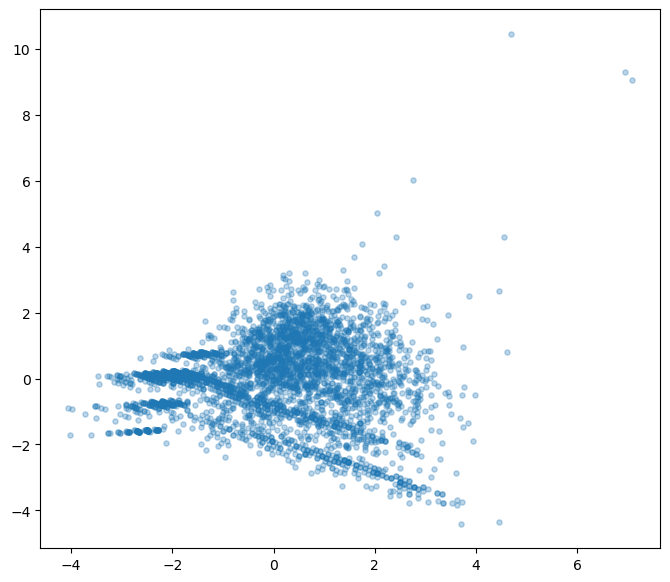

In [147]:
#3
# --- Biplot PCA (Scores + Loadings) ---

plt.figure(figsize=(8,7))

# 1) Puntos (scores)
plt.scatter(scores[:,0], scores[:,1], alpha=0.3, s=14)

# 2) Flechas (loadings)
for i, var in enumerate(loadings.index):
    plt.arrow(0, 0, x_loadings.iloc[i]*3, y_loadings.iloc[i]*3, 
              color='red', alpha=0.7, head_width=0.07)
    plt.text(x_loadings.iloc[i]*3.2, y_loadings.iloc[i]*3.2, var, 
             color='red', ha='center')

# 3) Ejes de referencia
plt.axhline(0, color='grey', lw=0.8)
plt.axvline(0, color='grey', lw=0.8)

# 4) Etiquetas
plt.xlabel(f'PC1 ({expl_var[0]:.1%} var. exp.)')
plt.ylabel(f'PC2 ({expl_var[1]:.1%} var. exp.)')
plt.title('Biplot de PCA: Scores y Loadings')

plt.tight_layout()
plt.show()

plt.savefig("biplot_pca.png", dpi=300, bbox_inches="tight")

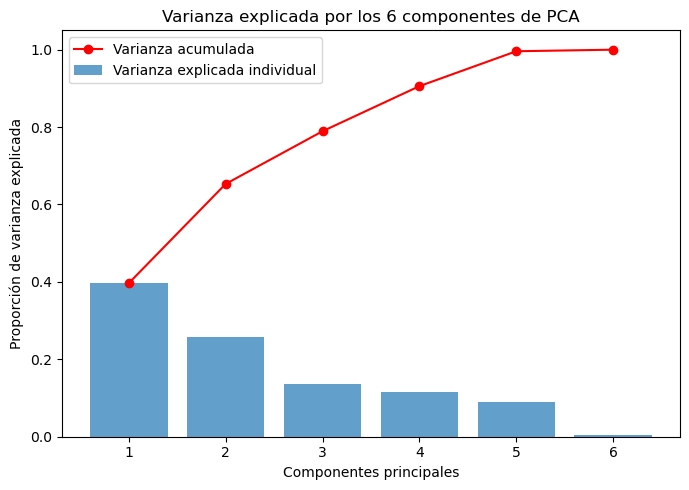

<Figure size 640x480 with 0 Axes>

In [148]:
#4
# --- Gráfico de varianza explicada (Scree Plot) ---

# PCA con los 6 componentes
pca_full = PCA(n_components=6, random_state=42)
pca_full.fit(Z)

# Varianza explicada
var_exp = pca_full.explained_variance_ratio_
cum_var_exp = var_exp.cumsum()

plt.figure(figsize=(7,5))

# Barras de varianza individual
plt.bar(range(1,7), var_exp, alpha=0.7, label='Varianza explicada individual')

# Línea acumulada
plt.plot(range(1,7), cum_var_exp, marker='o', color='red', label='Varianza acumulada')

# Ejes y etiquetas
plt.xlabel('Componentes principales')
plt.ylabel('Proporción de varianza explicada')
plt.title('Varianza explicada por los 6 componentes de PCA')
plt.xticks(range(1,7))
plt.legend()
plt.tight_layout()

plt.show()

plt.savefig("scree_plot_pca.png", dpi=300, bbox_inches="tight")

C:\Users\morad\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\morad\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\morad\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\morad\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

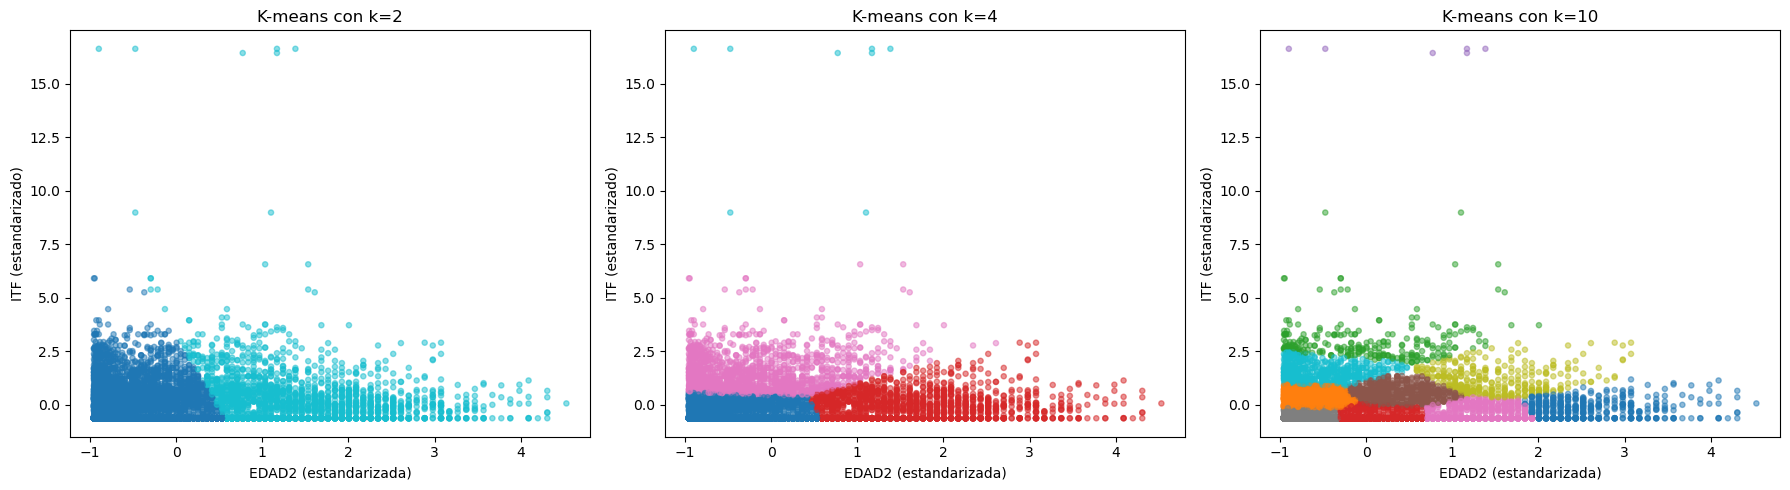

<Figure size 640x480 with 0 Axes>

In [149]:
#5a
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# --- Selección de variables: edad e ingreso total familiar
X_cluster = df_region[['EDAD2', 'ITF']].dropna()

# Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Lista de k a probar
k_list = [2, 4, 10]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, k in zip(axes, k_list):
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)

    # Scatter plot
    ax.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters, cmap='tab10', alpha=0.5, s=14)
    ax.set_title(f'K-means con k={k}')
    ax.set_xlabel('EDAD2 (estandarizada)')
    ax.set_ylabel('ITF (estandarizado)')

plt.tight_layout()
plt.show()
plt.savefig("kmeans_clusters2.png", dpi=300, bbox_inches="tight")


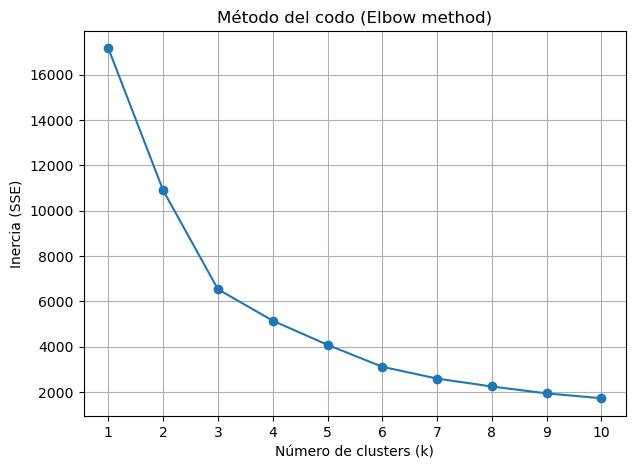

In [150]:
#5b graficamos y guardamos
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Variables a usar: edad e ingreso (estandarizados, como antes)
X_cluster = df_region[['EDAD2', 'ITF']].dropna()
X_scaled = scaler.fit_transform(X_cluster)   # usa el mismo scaler de antes

# Calcular inercia para k=1 a k=10
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Graficar elbow
plt.figure(figsize=(7,5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia (SSE)')
plt.title('Método del codo (Elbow method)')
plt.xticks(k_range)
plt.grid(True)

plt.savefig("elbow_method2.png", dpi=300, bbox_inches="tight")

plt.show()


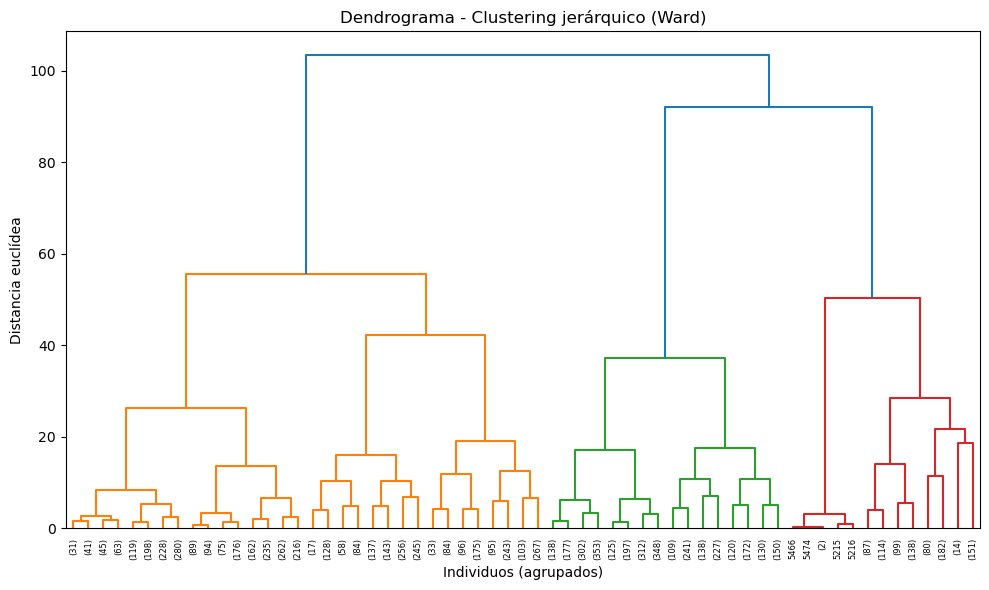

In [151]:
#ejercico 6
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Variables: EDAD e ITF (como en k-means)
X_cluster = df_region[['EDAD','ITF']].dropna()
X_scaled = scaler.fit_transform(X_cluster)

# Clustering jerárquico (método Ward = minimiza varianza intragrupo)
Z = linkage(X_scaled, method='ward')

# Dendrograma
plt.figure(figsize=(10, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p=5 muestra solo los últimos niveles
plt.title("Dendrograma - Clustering jerárquico (Ward)")
plt.xlabel("Individuos (agrupados)")
plt.ylabel("Distancia euclídea")
plt.tight_layout()

# Guardar
plt.savefig("dendrograma_cluster.png", dpi=300, bbox_inches="tight")
plt.show()


In [152]:
df_base.sample(20)

,CODUSU,NRO_HOGAR,COMPONENTE,H15,ANO4,TRIMESTRE,REGION,MAS_500,AGLOMERADO,PONDERA,...,HOGAR_ID,PERIODO,AE_HOGAR,CBT_AE_VAL,INGRESO_NECESARIO,POBRE,EDUC,EDAD2,HORASTRAB,IX_TOT
5688,TQRMNOSRWHKLKRCDEIHJF00860802,2,3,0,2025,1,44,N,31,156.0,...,TQRMNOSRWHKLKRCDEIHJF00860802_2,2025,1.80,356073.46,6.409322e+05,0,0.0,1,NaN,3
6050,TQRMNOVQUHJOKNCDEGNFJ00877409,1,2,1,2025,1,44,N,17,399.0,...,TQRMNOVQUHJOKNCDEGNFJ00877409_1,2025,3.92,356073.46,1.395808e+06,1,14.0,1681,NaN,5
1323,224875,1,1,Sí,2005,1,44,N,17,242.0,...,224875_1,2005,3.20,250.07,8.002240e+02,0,NaN,1444,44.0,4
7840,TQRMNOPWXHJOKRCDEGNFJ00873813,1,1,1,2025,1,44,N,17,161.0,...,TQRMNOPWXHJOKRCDEGNFJ00873813_1,2025,1.80,356073.46,6.409322e+05,0,17.0,1225,35.0,2
3168,281224,1,3,Sí,2005,1,44,N,31,108.0,...,281224_1,2005,5.10,250.07,1.275357e+03,0,17.0,289,0.0,7
3146,277857,1,2,Sí,2005,1,44,N,31,121.0,...,277857_1,2005,1.74,250.07,4.351218e+02,0,NaN,961,48.0,2
7828,TQRMNOQTYHKOKOCDEFPCH00860737,1,2,1,2025,1,44,N,9,259.0,...,TQRMNOQTYHKOKOCDEFPCH00860737_1,2025,2.78,356073.46,9.898842e+05,1,14.0,441,24.0,3
1175,192092,1,2,Sí,2005,1,44,N,17,166.0,...,192092_1,2005,1.74,250.07,4.351218e+02,0,6.0,3025,0.0,2
2314,261108,1,1,Sí,2005,1,44,N,20,90.0,...,261108_1,2005,4.62,250.07,1.155323e+03,0,6.0,2304,35.0,7
5404,TQRMNOPYPHMMLNCDEOJAH00879514,1,3,1,2025,1,44,N,93,166.0,...,TQRMNOPYPHMMLNCDEOJAH00879514_1,2025,2.80,356073.46,9.970057e+05,1,17.0,361,NaN,3


In [153]:
list(df_base.columns)


['CODUSU',
 'NRO_HOGAR',
 'COMPONENTE',
 'H15',
 'ANO4',
 'TRIMESTRE',
 'REGION',
 'MAS_500',
 'AGLOMERADO',
 'PONDERA',
 'CH03',
 'CH04',
 'EDAD',
 'CH07',
 'CH08',
 'CH09',
 'CH10',
 'CH11',
 'CH12',
 'CH13',
 'CH14',
 'CH15',
 'CH15_COD',
 'CH16',
 'CH16_COD',
 'NIVEL_ED',
 'ESTADO',
 'CAT_OCUP',
 'CAT_INAC',
 'PP02C1',
 'PP02C2',
 'PP02C3',
 'PP02C4',
 'PP02C5',
 'PP02C6',
 'PP02C7',
 'PP02C8',
 'PP02E',
 'PP02H',
 'PP02I',
 'PP03C',
 'PP03D',
 'PP3E_TOT',
 'PP3F_TOT',
 'PP03G',
 'PP03H',
 'PP03I',
 'PP03J',
 'INTENSI',
 'PP04A',
 'PP04B_COD',
 'PP04B1',
 'PP04B2',
 'PP04B3_MES',
 'PP04B3_ANO',
 'PP04B3_DIA',
 'PP04C',
 'PP04C99',
 'PP04D_COD',
 'PP04G',
 'PP05B2_MES',
 'PP05B2_ANO',
 'PP05B2_DIA',
 'PP05C_1',
 'PP05C_2',
 'PP05C_3',
 'PP05E',
 'PP05F',
 'PP05H',
 'PP06A',
 'PP06C',
 'PP06D',
 'PP06E',
 'PP06H',
 'PP07A',
 'PP07C',
 'PP07D',
 'PP07E',
 'PP07F1',
 'PP07F2',
 'PP07F3',
 'PP07F4',
 'PP07F5',
 'PP07G1',
 'PP07G2',
 'PP07G3',
 'PP07G4',
 'PP07G_59',
 'PP07H',
 'PP07I',


In [154]:
A partir de aca es TP3

SyntaxError: invalid syntax (2602823305.py, line 1)

In [160]:
# Lista de variables que querés conservar
vars_tp3 = ["EDAD", "EDAD2", "ITF", "IX_TOT", "CH04", "ANO4","ESTADO", "CH08", "POBRE", "INGRESO_NECESARIO"]

# Crear la nueva base (solo esas columnas)
base_tp3 = df_base[vars_tp3]

In [161]:
base_tp3.sample(20)

,EDAD,EDAD2,ITF,IX_TOT,CH04,ANO4,ESTADO,CH08,POBRE,INGRESO_NECESARIO
6865,62,3844,1800000.0,2,2,2025,3,1,0,5.198673e+05
113,45,2025,4220.0,8,2,2005,1,1,0,1.562938e+03
2486,32,1024,1873.0,7,2,2005,1,4,0,1.385388e+03
459,61,3721,335.0,2,2,2005,3,4,1,4.101148e+02
7760,64,4096,0.0,4,1,2025,3,1,1,1.046856e+06
2304,26,676,2054.0,4,1,2005,1,1,0,7.327051e+02
4719,76,5776,1326000.0,2,1,2025,3,1,0,5.198673e+05
5468,26,676,1000000.0,2,2,2025,1,1,0,6.409322e+05
273,35,1225,2300.0,5,2,2005,3,1,0,1.030288e+03
1240,31,961,150.0,4,2,2005,1,4,1,7.977233e+02


In [162]:
# Convertir ITF a numérico (por si hay strings u otros errores)
base_tp3['ITF'] = pd.to_numeric(base_tp3['ITF'], errors='coerce')


C:\Users\morad\AppData\Local\Temp\ipykernel_7428\4275998190.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base_tp3['ITF'] = pd.to_numeric(base_tp3['ITF'], errors='coerce')


In [163]:
# Respondieron: ITF > 0
respondieron_tp3 = base_tp3[base_tp3['ITF'] > 0].copy()

# No respondieron: ITF == 0 o NaN o negativo
norespondieron_tp3 = base_tp3[(base_tp3['ITF'] <= 0) | (base_tp3['ITF'].isna())].copy()
import numpy as np

# Reemplazar todos los valores por NA
norespondieron_tp3['POBRE'] = np.nan



In [164]:
respondieron_tp3.sample(20)

,EDAD,EDAD2,ITF,IX_TOT,CH04,ANO4,ESTADO,CH08,POBRE,INGRESO_NECESARIO
5366,10,100,1500000.0,4,2,2025,3,1,0,1.221332e+06
7197,38,1444,268000.0,6,2,2025,3,4,1,1.833778e+06
559,22,484,1900.0,5,2,2005,1,1,0,8.777457e+02
2627,35,1225,2430.0,6,1,2005,1,1,0,1.085304e+03
5463,53,2809,1800000.0,2,2,2025,1,1,0,6.409322e+05
938,43,1849,850.0,5,2,2005,1,4,1,1.135318e+03
2941,52,2704,6900.0,2,1,2005,1,1,0,4.351218e+02
2797,5,25,1800.0,8,2,2005,4,1,0,1.560437e+03
7524,19,361,828000.0,5,2,2025,2,4,1,1.388686e+06
4735,77,5929,1700000.0,2,2,2025,3,1,0,5.839605e+05


In [165]:
norespondieron_tp3.sample(20)

,EDAD,EDAD2,ITF,IX_TOT,CH04,ANO4,ESTADO,CH08,POBRE,INGRESO_NECESARIO
7024,11,121,0.0,4,1,2025,3,4,NaN,1.288986e+06
5283,37,1369,0.0,3,1,2025,1,1,NaN,8.474548e+05
3766,15,225,0.0,4,1,2025,3,1,NaN,1.221332e+06
5173,73,5329,0.0,2,1,2025,3,1,NaN,5.198673e+05
6347,41,1681,0.0,3,1,2025,1,4,NaN,8.759407e+05
6477,35,1225,0.0,2,2,2025,1,1,NaN,4.878206e+05
6109,2,4,0.0,7,1,2025,4,1,NaN,2.075908e+06
3247,10,100,0.0,3,1,2025,3,1,NaN,8.403334e+05
3446,56,3136,0.0,7,2,2025,3,4,NaN,2.090151e+06
7682,60,3600,0.0,3,1,2025,1,1,NaN,9.329125e+05


In [166]:
#calculo los tamaños de las bases y comparo
# Cantidad de observaciones en cada base
n_total = len(base_tp3)
n_resp = len(respondieron_tp3)
n_noresp = len(norespondieron_tp3)

print("Total:", n_total)
print("Respondieron:", n_resp)
print("No respondieron:", n_noresp)


Total: 8588
Respondieron: 7363
No respondieron: 1225


In [167]:
porc_resp = (n_resp / n_total) * 100
porc_noresp = (n_noresp / n_total) * 100

print(f"\nPorcentaje que respondieron: {porc_resp:.2f}%")
print(f"Porcentaje que no respondieron: {porc_noresp:.2f}%")



Porcentaje que respondieron: 85.74%
Porcentaje que no respondieron: 14.26%


In [168]:
#PARTE UNO EJ 0 (separo la base respondieron en train y test)
from sklearn.model_selection import train_test_split

X = respondieron_tp3.drop(columns=['POBRE', 'ITF'])
y = respondieron_tp3['POBRE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=444)


In [169]:
#cheque los tamaños de los train y tests 
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (5154, 8)
X_test: (2209, 8)
y_train: (5154,)
y_test: (2209,)


In [170]:
#EJ 1 ( aca voy a chequea que la particion no haya sesgado las mustras haciendo test de students para ver que no haya diferencias significativas entre nuestras variables de entrenamiento y teste)
import pandas as pd
from scipy.stats import ttest_ind
# Media y desvío en train
media_train = X_train.mean()
desvio_train = X_train.std()

# Media y desvío en test
media_test = X_test.mean()
desvio_test = X_test.std()


In [171]:
t_stat = []
p_val = []

for col in X_train.columns:
    # usar 'nan_policy="omit"' por si alguna columna tiene NA
    t, p = ttest_ind(X_train[col], X_test[col], nan_policy='omit')
    t_stat.append(t)
    p_val.append(p)


In [172]:
tabla_diff = pd.DataFrame({
    'Media_Train': media_train,
    'Desvio_Train': desvio_train,
    'Media_Test': media_test,
    'Desvio_Test': desvio_test,
    't_stat': t_stat,
    'p_valor': p_val
})

# Redondear para que quede prolijo
tabla_diff = tabla_diff.round(3)
tabla_diff


,Media_Train,Desvio_Train,Media_Test,Desvio_Test,t_stat,p_valor
EDAD,34.326,21.607,33.756,21.732,1.035,0.301
EDAD2,1645.023,1737.208,1611.531,1735.693,0.758,0.448
IX_TOT,3.773,1.894,3.817,1.94,-0.900,0.368
CH04,1.507,0.5,1.516,0.5,-0.730,0.465
ANO4,2016.339,9.911,2016.182,9.932,0.623,0.533
ESTADO,2.255,1.144,2.314,1.14,-2.015,0.044
CH08,1.762,1.42,1.797,1.451,-0.959,0.337
INGRESO_NECESARIO,548906.151,603846.294,538827.085,609775.766,0.654,0.513


In [174]:
tabla_diff['Significativo'] = tabla_diff['p_valor'] < 0.05
tabla_diff


,Media_Train,Desvio_Train,Media_Test,Desvio_Test,t_stat,p_valor,Significativo
EDAD,34.326,21.607,33.756,21.732,1.035,0.301,False
EDAD2,1645.023,1737.208,1611.531,1735.693,0.758,0.448,False
IX_TOT,3.773,1.894,3.817,1.94,-0.900,0.368,False
CH04,1.507,0.5,1.516,0.5,-0.730,0.465,False
ANO4,2016.339,9.911,2016.182,9.932,0.623,0.533,False
ESTADO,2.255,1.144,2.314,1.14,-2.015,0.044,True
CH08,1.762,1.42,1.797,1.451,-0.959,0.337,False
INGRESO_NECESARIO,548906.151,603846.294,538827.085,609775.766,0.654,0.513,False


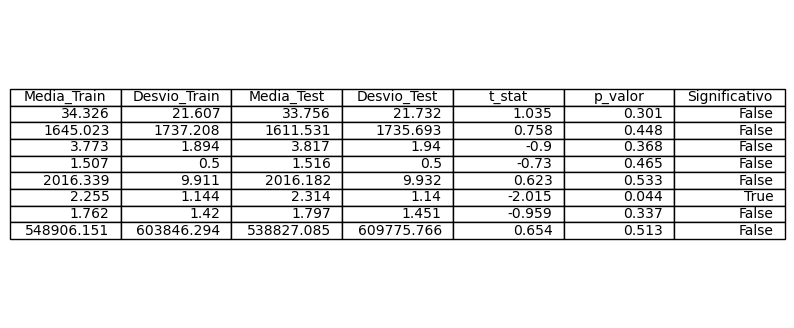

In [175]:
#descargo foto de la tabla para el informe

import matplotlib.pyplot as plt

# Ajustar tamaño de figura
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')

# Crear tabla a partir del DataFrame
tabla_img = ax.table(
    cellText=tabla_diff.round(3).values,
    colLabels=tabla_diff.columns,
    loc='center'
)

# Guardar como imagen PNG
plt.savefig("tabla_diferencia_medias.png", dpi=300, bbox_inches='tight')
plt.show()

In [176]:
#ej 2 aca separo por 2005 y 2025
# --- Separar respondieron por año ---
respondieron_2005 = respondieron_tp3[respondieron_tp3['ANO4'] == 2005].copy()
respondieron_2025 = respondieron_tp3[respondieron_tp3['ANO4'] == 2025].copy()

# --- Separar norespondieron por año ---
norespondieron_2005 = norespondieron_tp3[norespondieron_tp3['ANO4'] == 2005].copy()
norespondieron_2025 = norespondieron_tp3[norespondieron_tp3['ANO4'] == 2025].copy()


In [179]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1) Defino y como 0/1 int NumPy
y = respondieron_tp3['POBRE'].astype(int)

# 2) Predictores: saco 'POBRE' e 'ITF'
X = respondieron_tp3.drop(columns=['POBRE', 'ITF']).copy()

# 3) One-hot si queda algo no numérico (por si CH04/ESTADO/CH08 u otros quedaron como 'object')
#    Si todas tus columnas ya son numéricas, esto no molesta.
X = pd.get_dummies(X, drop_first=True)

# 4) Fuerzo a numérico y convierto dtypes "pandas" (Int64) a float de NumPy
X = X.apply(pd.to_numeric, errors='coerce').astype(float)

# 5) Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=444
)

# 6) Dropeo filas con NaN SOLO en el train (statsmodels no admite NaN)
mask = X_train.notna().all(axis=1)
X_train = X_train[mask]
y_train = y_train.loc[mask]



In [180]:
print(X_train.dtypes.unique())   # debería mostrar float64
print(X_train.isna().sum().sum())  # 0
print(y_train.dtype)  # int64


[dtype('float64')]
0
int64


In [181]:

import statsmodels.api as sm

X_train_const = sm.add_constant(X_train)
logit = sm.Logit(y_train, X_train_const)
res = logit.fit()
print(res.summary())



Optimization terminated successfully.
         Current function value: 0.418296
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  POBRE   No. Observations:                 5154
Model:                          Logit   Df Residuals:                     5145
Method:                           MLE   Df Model:                            8
Date:                Thu, 30 Oct 2025   Pseudo R-squ.:                  0.1940
Time:                        19:03:29   Log-Likelihood:                -2155.9
converged:                       True   LL-Null:                       -2674.8
Covariance Type:            nonrobust   LLR p-value:                1.076e-218
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               -41.9306     19.941     -2.103      0.035     -81.014      -2.847
EDAD    

,Variable,Coeficiente,Error_Estandar,p_valor,Odds_Ratio
0,const,-41.9306,19.9411,0.0355,0.0000
1,EDAD,0.0301,0.0097,0.0020,1.0305
2,EDAD2,-0.0004,0.0001,0.0013,0.9996
3,IX_TOT,0.3724,0.0293,0.0000,1.4512
4,CH04,0.1121,0.0791,0.1563,1.1187
5,ANO4,0.0181,0.0099,0.0671,1.0183
6,ESTADO,0.4236,0.0534,0.0000,1.5275
7,CH08,0.4936,0.0268,0.0000,1.6382
8,INGRESO_NECESARIO,0.0000,0.0000,0.7113,1.0000


,Variable,AME,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
0,EDAD,0.0040,0.0013,3.0981,0.0019,0.0015,0.0065
1,EDAD2,-0.0001,0.0000,-3.2281,0.0012,-0.0001,-0.0000
2,IX_TOT,0.0490,0.0037,13.3593,0.0000,0.0418,0.0562
3,CH04,0.0148,0.0104,1.4185,0.1560,-0.0056,0.0351
4,ANO4,0.0024,0.0013,1.8333,0.0668,-0.0002,0.0049
5,ESTADO,0.0557,0.0069,8.0530,0.0000,0.0422,0.0693
6,CH08,0.0649,0.0031,20.6856,0.0000,0.0588,0.0711
7,INGRESO_NECESARIO,0.0000,0.0000,0.3701,0.7113,-0.0000,0.0000


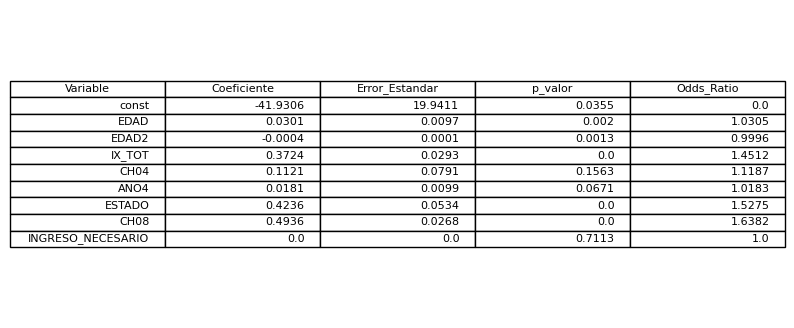

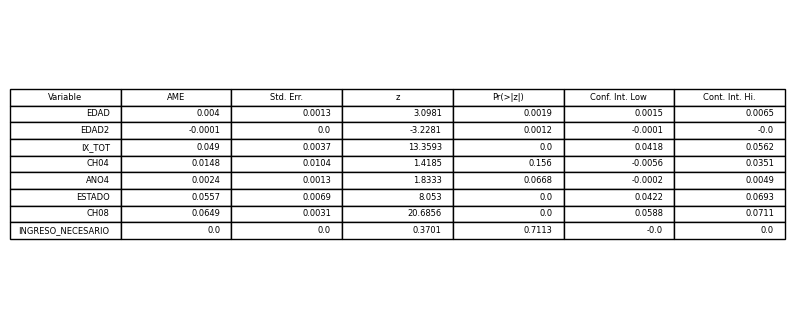

In [182]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# === 1) TABLA PRINCIPAL DEL LOGIT ===
tabla_logit = pd.DataFrame({
    'Variable': res.params.index,
    'Coeficiente': res.params.values,
    'Error_Estandar': res.bse.values,
    'p_valor': res.pvalues.values,
    'Odds_Ratio': np.exp(res.params.values)
}).round(4)

# Mostrar tabla
display(tabla_logit)

# === 2) EFECTOS MARGINALES (AME) ===
mfx = res.get_margeff(at='overall', method='dydx')
tabla_mfx = mfx.summary_frame().reset_index()
tabla_mfx = tabla_mfx.rename(columns={'dy/dx': 'AME', 'index': 'Variable'}).round(4)

# Mostrar tabla
display(tabla_mfx)

# === 3) OPCIONAL: GUARDAR LAS DOS TABLAS COMO IMÁGENES ===
def save_table(df, fname, figsize=(10,4)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off'); ax.axis('tight')
    ax.table(cellText=df.values, colLabels=df.columns, loc='center')
    plt.savefig(fname, dpi=300, bbox_inches='tight'); plt.show()

save_table(tabla_logit, "tabla_logit_tp3.png")
save_table(tabla_mfx, "tabla_efectos_marginales_tp3.png")



AUC: 0.821


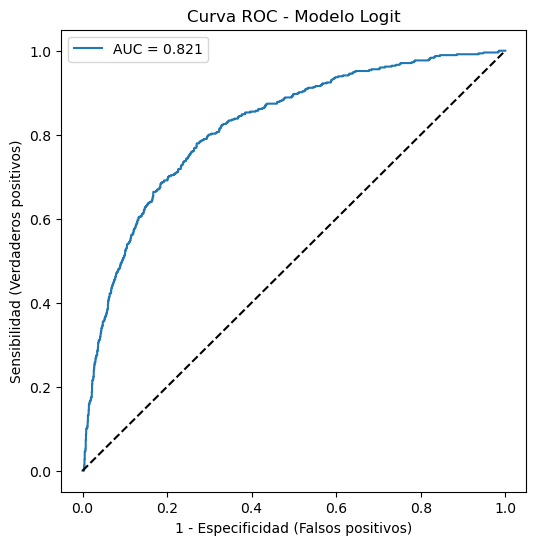

In [183]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Predicciones de probabilidad
y_pred_prob = res.predict(sm.add_constant(X_test))

# AUC
auc = roc_auc_score(y_test, y_pred_prob)
print(f"AUC: {auc:.3f}")

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('1 - Especificidad (Falsos positivos)')
plt.ylabel('Sensibilidad (Verdaderos positivos)')
plt.title('Curva ROC - Modelo Logit')
plt.legend()
plt.show()


AUC: 0.821


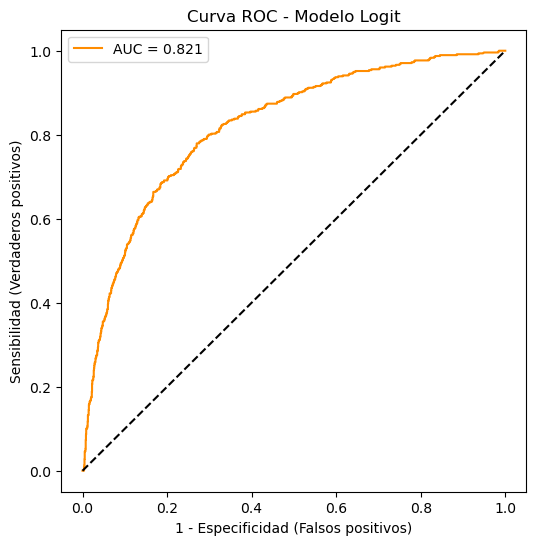

In [184]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import statsmodels.api as sm

# === 1) Predicciones ===
y_pred_prob = res.predict(sm.add_constant(X_test))

# === 2) Calcular AUC ===
auc = roc_auc_score(y_test, y_pred_prob)
print(f"AUC: {auc:.3f}")

# === 3) Curva ROC ===
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('1 - Especificidad (Falsos positivos)')
plt.ylabel('Sensibilidad (Verdaderos positivos)')
plt.title('Curva ROC - Modelo Logit')
plt.legend()

# === 4) Guardar la figura ===
plt.savefig("curva_ROC_Logit_TP3.png", dpi=300, bbox_inches='tight')
plt.show()


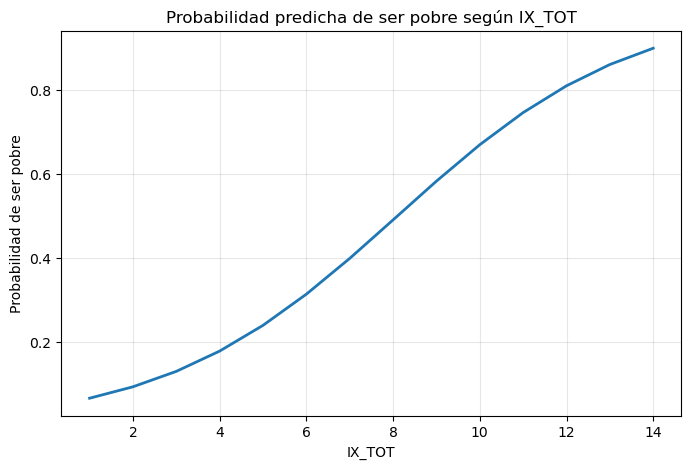

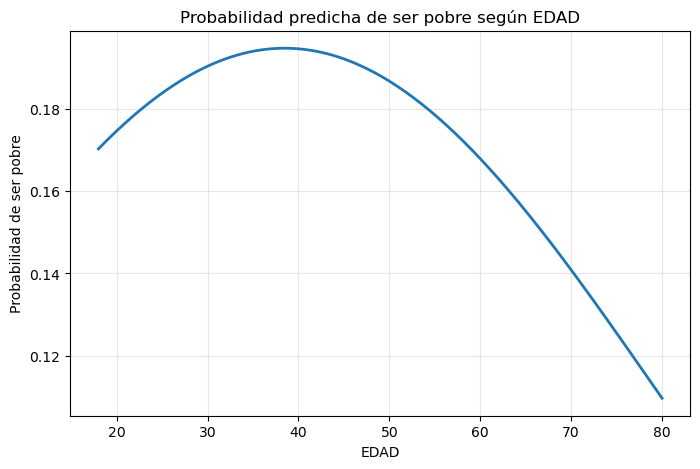

In [188]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# === 1) Preparo "la plantilla" con las MISMAS columnas y orden que el modelo ===
X_train_const = sm.add_constant(X_train)                 # lo mismo que usaste para entrenar
cols_modelo = X_train_const.columns                      # orden exacto de columnas

# valores promedio de las variables (en el mismo orden)
fila_media_const = pd.Series(sm.add_constant(X_train).mean(), index=cols_modelo)

def grafico_prob_por_variable(var, grid, fname):
    """
    var: nombre de la variable numérica (string) tal como está en X_train
    grid: array/lista con los valores del eje X para esa variable
    fname: nombre de archivo PNG a guardar
    """
    # replico la fila media tantas veces como puntos tenga el grid
    X_plot_const = pd.DataFrame([fila_media_const.values]*len(grid), columns=cols_modelo)

    # seteo la variable elegida al grid
    X_plot_const[var] = grid

    # si la variable elegida es 'EDAD' y existe 'EDAD2', la recalculo para que sea consistente
    if var == 'EDAD' and 'EDAD2' in X_plot_const.columns:
        X_plot_const['EDAD2'] = grid**2

    # predicciones
    y_pred_prob = res.predict(X_plot_const)

    # grafico
    plt.figure(figsize=(8,5))
    plt.plot(grid, y_pred_prob, linewidth=2)
    plt.title(f'Probabilidad predicha de ser pobre según {var}')
    plt.xlabel(var)
    plt.ylabel('Probabilidad de ser pobre')
    plt.grid(True, alpha=0.3)
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()

# === 2) EJEMPLO A: usar IX_TOT (tamaño del hogar) ===
grid_ix = np.arange(int(X_train['IX_TOT'].min()), int(X_train['IX_TOT'].max())+1)
grafico_prob_por_variable('IX_TOT', grid_ix, 'probabilidad_pobre_IX_TOT.png')

# === 3) EJEMPLO B: usar EDAD (si querés ese también) ===
grid_edad = np.linspace(18, 80, 200)
grafico_prob_por_variable('EDAD', grid_edad, 'probabilidad_pobre_EDAD.png')


In [189]:
#a partir de aca es parte c
#ahora tengo que hace vecinos cercanos. 
#lo primero qque hago es estandarizar los daots 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [190]:
#entreno el modelo
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

for k in [1, 5, 10]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"K = {k} → Exactitud: {acc:.3f}")
    print(confusion_matrix(y_test, y_pred))
    print("--------------------")


K = 1 → Exactitud: 0.756
[[1466  267]
 [ 273  203]]
--------------------
K = 5 → Exactitud: 0.810
[[1577  156]
 [ 264  212]]
--------------------
K = 10 → Exactitud: 0.816
[[1631  102]
 [ 305  171]]
--------------------


C:\Users\morad\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


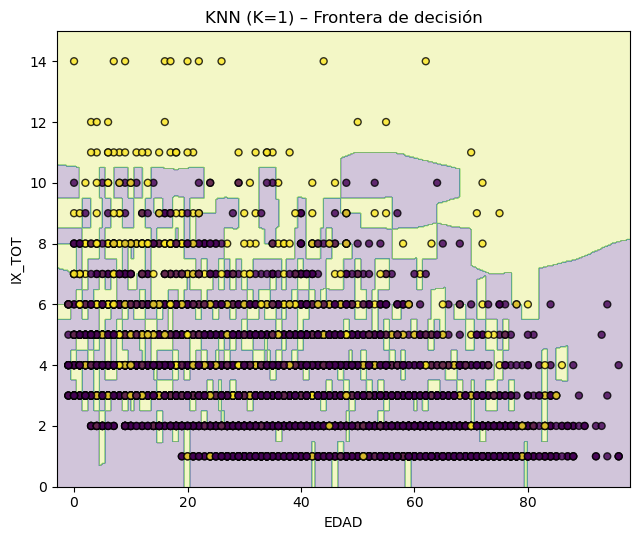

C:\Users\morad\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


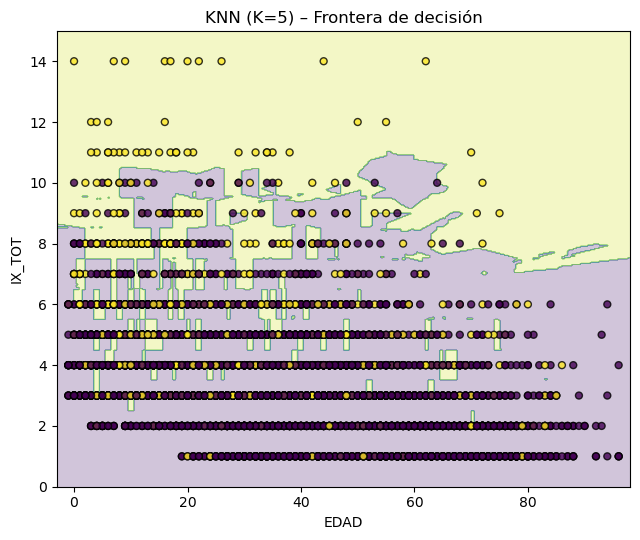

C:\Users\morad\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


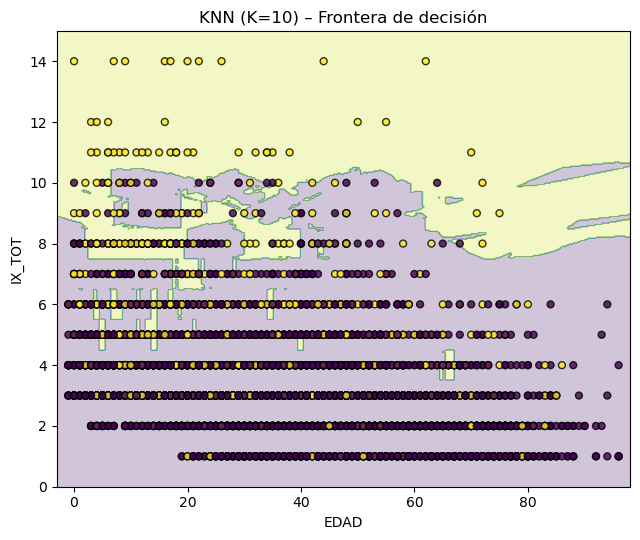

In [191]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# ===== 1) Elegí dos variables NUMÉRICAS de X_train =====
feat_x = 'EDAD'
feat_y = 'IX_TOT'

X2_train = X_train[[feat_x, feat_y]].copy()
y_tr = y_train.copy()

# Escalado (muy importante para KNN)
scaler2 = StandardScaler()
X2_train_sc = scaler2.fit_transform(X2_train)

# ===== 2) Función para graficar frontera de decisión =====
def plot_knn_boundary(k, X_sc, y, scaler, features, fname):
    # Rango de malla en el espacio NO escalado (para etiquetar ejes lindos)
    x_min, x_max = X_train[features[0]].min()-2, X_train[features[0]].max()+2
    y_min, y_max = X_train[features[1]].min()-1, X_train[features[1]].max()+1

    # Malla densa en el espacio original y luego la escalo
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_sc = scaler.transform(grid)

    # Modelo KNN con K dado
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_sc, y)

    Z = knn.predict(grid_sc).reshape(xx.shape)

    # Plot
    plt.figure(figsize=(6.5,5.5))
    plt.contourf(xx, yy, Z, alpha=0.25)          # fondo por clase (pobre/no pobre)
    # puntos de entrenamiento
    plt.scatter(X_train[features[0]], X_train[features[1]],
                c=y.values, edgecolor='k', s=25, alpha=0.8)
    plt.xlabel(features[0]); plt.ylabel(features[1])
    plt.title(f'KNN (K={k}) – Frontera de decisión')
    plt.tight_layout()
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()

# ===== 3) Graficar para K = 1, 5 y 10 =====
for k in [1,5,10]:
    plot_knn_boundary(
        k=k,
        X_sc=X2_train_sc,
        y=y_tr,
        scaler=scaler2,
        features=[feat_x, feat_y],
        fname=f'knn_frontera_{feat_x}_{feat_y}_K{k}.png'
    )


K óptimo: 14 con Accuracy promedio: 0.806


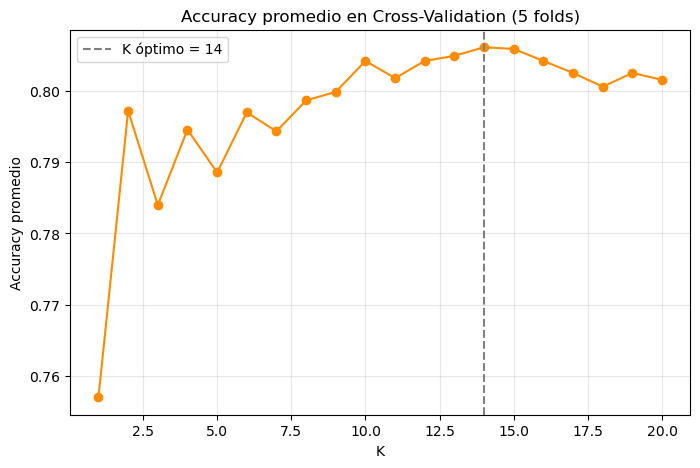

In [192]:
#ejercicio 7 k folds
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# === 1. Preparo los datos de 2025 ===
X_2025 = respondieron_2025.drop(columns=['POBRE', 'ITF'])
y_2025 = respondieron_2025['POBRE']

# Escalar
scaler = StandardScaler()
X_2025_scaled = scaler.fit_transform(X_2025)

# === 2. Defino rango de Ks para probar ===
k_values = range(1, 21)
cv_scores = []

# === 3. Cross-Validation con 5 folds ===
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_2025_scaled, y_2025, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# === 4. Encuentro el K óptimo ===
best_k = k_values[np.argmax(cv_scores)]
best_acc = max(cv_scores)
print(f"K óptimo: {best_k} con Accuracy promedio: {best_acc:.3f}")

# === 5. Gráfico de Accuracy por K ===
plt.figure(figsize=(8,5))
plt.plot(k_values, cv_scores, marker='o', color='darkorange')
plt.title('Accuracy promedio en Cross-Validation (5 folds)')
plt.xlabel('K')
plt.ylabel('Accuracy promedio')
plt.grid(alpha=0.3)
plt.axvline(x=best_k, color='gray', linestyle='--', label=f'K óptimo = {best_k}')
plt.legend()
plt.savefig("KNN_CV_accuracy.png", dpi=300, bbox_inches='tight')
plt.show()


=== LOGIT ===
Accuracy: 0.823 | Precisión: 0.676 | Recall: 0.338 | AUC: 0.821
[[1656   77]
 [ 315  161]]

=== KNN (K=14, CV) ===
Accuracy: 0.817 | Precisión: 0.638 | Recall: 0.345 | AUC: 0.809
[[1640   93]
 [ 312  164]]


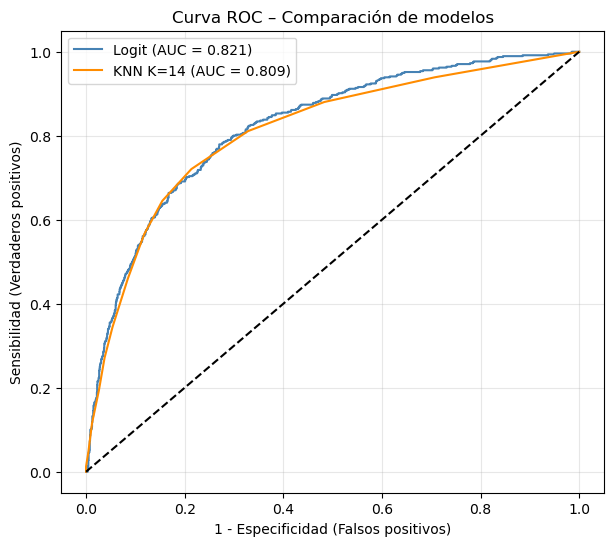

In [193]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve
)
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

# === 1. Predicciones del modelo LOGIT ===
y_pred_prob_logit = res.predict(sm.add_constant(X_test))   # probabilidad
y_pred_logit = (y_pred_prob_logit > 0.5).astype(int)       # clasifica 1 si p>0.5

# === 2. Entreno el modelo KNN con K óptimo (14) ===
knn_cv = KNeighborsClassifier(n_neighbors=14)
knn_cv.fit(X_train_scaled, y_train)
y_pred_knn = knn_cv.predict(X_test_scaled)
y_pred_prob_knn = knn_cv.predict_proba(X_test_scaled)[:,1]

# === 3. Métricas de evaluación ===
def evaluar_modelo(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    return acc, prec, rec, auc

acc_l, prec_l, rec_l, auc_l = evaluar_modelo(y_test, y_pred_logit, y_pred_prob_logit)
acc_k, prec_k, rec_k, auc_k = evaluar_modelo(y_test, y_pred_knn, y_pred_prob_knn)

print("=== LOGIT ===")
print(f"Accuracy: {acc_l:.3f} | Precisión: {prec_l:.3f} | Recall: {rec_l:.3f} | AUC: {auc_l:.3f}")
print(confusion_matrix(y_test, y_pred_logit))

print("\n=== KNN (K=14, CV) ===")
print(f"Accuracy: {acc_k:.3f} | Precisión: {prec_k:.3f} | Recall: {rec_k:.3f} | AUC: {auc_k:.3f}")
print(confusion_matrix(y_test, y_pred_knn))

# === 4. Curva ROC comparada ===
fpr_l, tpr_l, _ = roc_curve(y_test, y_pred_prob_logit)
fpr_k, tpr_k, _ = roc_curve(y_test, y_pred_prob_knn)

plt.figure(figsize=(7,6))
plt.plot(fpr_l, tpr_l, color='steelblue', label=f'Logit (AUC = {auc_l:.3f})')
plt.plot(fpr_k, tpr_k, color='darkorange', label=f'KNN K=14 (AUC = {auc_k:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('1 - Especificidad (Falsos positivos)')
plt.ylabel('Sensibilidad (Verdaderos positivos)')
plt.title('Curva ROC – Comparación de modelos')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("comparacion_ROC_Logit_vs_KNN.png", dpi=300, bbox_inches='tight')
plt.show()


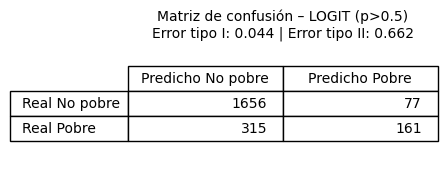

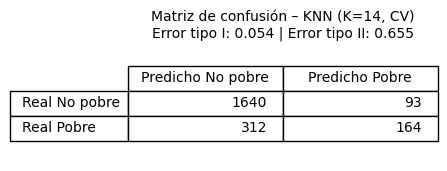

In [198]:
#hago las tablitas de confusion exportables
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def matriz_tabla(y_true, y_pred, modelo, fname):
    cm = confusion_matrix(y_true, y_pred)
    df_cm = pd.DataFrame(cm, 
                         index=["Real No pobre", "Real Pobre"],
                         columns=["Predicho No pobre", "Predicho Pobre"])
    
    # Calcular errores tipo I y II
    tn, fp, fn, tp = cm.ravel()
    err_tipo1 = fp / (tn + fp)
    err_tipo2 = fn / (fn + tp)
    
    # Mostrar tabla con matplotlib
    fig, ax = plt.subplots(figsize=(4, 1.5))
    ax.axis('off')
    ax.axis('tight')
    tabla = ax.table(cellText=df_cm.values,
                     colLabels=df_cm.columns,
                     rowLabels=df_cm.index,
                     loc='center')
    tabla.scale(1, 1.5)
    plt.title(f"{modelo}\nError tipo I: {err_tipo1:.3f} | Error tipo II: {err_tipo2:.3f}", fontsize=10)
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    
    return df_cm, err_tipo1, err_tipo2

# === LOGIT ===
tabla_logit, err1_logit, err2_logit = matriz_tabla(
    y_test, y_pred_logit, 
    modelo="Matriz de confusión – LOGIT (p>0.5)", 
    fname="matriz_tabla_logit.png"
)

# === KNN (K=14) ===
tabla_knn, err1_knn, err2_knn = matriz_tabla(
    y_test, y_pred_knn, 
    modelo="Matriz de confusión – KNN (K=14, CV)", 
    fname="matriz_tabla_knn.png"
)


In [200]:
#ej 10 comparcion con noerspondieron
import pandas as pd
import numpy as np

# 1) Preparar X_new como antes (sin 'POBRE' ni 'ITF', numérico)
X_new = norespondieron_2025.drop(columns=[c for c in ['POBRE','ITF'] if c in norespondieron_2025.columns], errors='ignore')
X_new = pd.get_dummies(X_new, drop_first=True).apply(pd.to_numeric, errors='coerce').astype(float)

# 2) Alinear columnas con las usadas por el modelo (incluye const)
exog_names = res.model.exog_names            # e.g. ['const','EDAD','EDAD2',...]
X_new_const = pd.DataFrame(0.0, index=X_new.index, columns=exog_names)

# 3) Setear la constante y completar las que existan
if 'const' in X_new_const.columns:
    X_new_const['const'] = 1.0
for c in X_new.columns:
    if c in X_new_const.columns:
        X_new_const[c] = X_new[c].values

# 4) Predecir con exactamente ese orden de columnas
p_hat = res.predict(X_new_const[exog_names])
y_hat = (p_hat > 0.5).astype(int)

prop_pobre = float(y_hat.mean())
n_pred_pobres = int(y_hat.sum())
n_total = len(y_hat)

print(f"Identificados como pobres: {n_pred_pobres} de {n_total}  →  Proporción = {prop_pobre:.3%}")

# (opcional) exportar
salida = norespondieron_2025.copy()
salida['p_logit'] = p_hat.values
salida['pred_logit'] = y_hat.values
salida.to_csv("norespondieron_2025_pred_logit.csv", index=False)


Identificados como pobres: 121 de 1202  →  Proporción = 10.067%
